# ============================================
# AGRI-WATCH Sénégal
# Notebook 01 - Exploration des données geospatiales
# Auteure : Adji Fatou NGOM - ANSD
# ============================================

In [49]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Ajout de la racine du projet au path Python
if "C:/AGRI-WATCH" not in sys.path:
    sys.path.append("C:/AGRI-WATCH")

# Nettoyage du cache des modules AGRI-WATCH
# Necessaire pour recharger les modifications de config.py
for module in list(sys.modules.keys()):
    if module.startswith('src'):
        del sys.modules[module]

print("Path et cache initialises avec succes.")

Path et cache initialises avec succes.


## Initialisation du projet AGRI-WATCH

La premiere cellule initialise l'environnement de travail du projet AGRI-WATCH Sénégal.

**Ce qui a été fait :**
- Le chemin racine du projet `C:/AGRI-WATCH` a été ajouté au path Python
  pour permettre l'importation des modules `src/`
- Le cache des modules a été nettoyé pour forcer le rechargement
  des dernières modifications de `config.py`

**Pourquoi c'est important :**
Sans cette initialisation, Python ne trouverait pas les modules
`src/config.py` et `src/logger.py` qui contiennent toute la
configuration centralisée du projet.

In [50]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Bibliotheques scientifiques importees avec succes.")

Bibliotheques scientifiques importees avec succes.


## Bibliothèques scientifiques

Les bibliothèques suivantes ont été importées avec succès :

| Bibliothèque | Rôle dans AGRI-WATCH |
|---|---|
| `geopandas` | Manipulation des shapefiles et données géospatiales |
| `pandas` | Manipulation des tableaux de données agricoles |
| `numpy` | Calculs mathématiques sur les rasters NDVI et SPI |
| `matplotlib` | Génération des cartes et graphiques |

Ces bibliothèques constituent le socle scientifique sur lequel
repose l'ensemble des analyses d'AGRI-WATCH.

In [51]:
from src.config import (
    SHAPEFILE_REGIONS,
    SHAPEFILE_DEPARTEMENTS,
    SHAPEFILE_COMMUNES,
    COL_NOM_REGION,
    COL_NOM_DEPARTEMENT,
    COL_NOM_COMMUNE,
    COULEURS_CULTURES,
    COULEURS_RISQUE,
    FIGURE_SIZE_CARTE,
    creer_dossiers
)
from src.logger import get_logger

# Initialisation
creer_dossiers()
logger = get_logger("exploration")
logger.info("Notebook 01 - Exploration des donnees - Demarrage")
print("Imports AGRI-WATCH reussis !")

Structure des dossiers AGRI-WATCH verifiee avec succes.
Racine du projet : C:\AGRI-WATCH
[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Notebook 01 - Exploration des donnees - Demarrage
Imports AGRI-WATCH reussis !


## Configuration AGRI-WATCH

La configuration centrale du projet a été chargée depuis `src/config.py`.

**Paramètres chargés :**
- Chemins des shapefiles des 3 niveaux administratifs
- Noms des colonnes dans les fichiers GADM
- Couleurs officielles AGRI-WATCH pour les cartes de risque
- Taille des figures pour les visualisations

**Logger initialisé :**
Le système de logging est actif, toutes les actions importantes
seront tracées dans `logs/agriwatch_YYYYMMDD.log` pour permettre
le débogage et l'audit des traitements.

**Structure des dossiers vérifiée :**
Tous les dossiers nécessaires au projet existent et sont accessibles.

In [37]:
# Chargement des 3 niveaux administratifs
logger.info("Chargement des shapefiles...")

# Chargement des régions
regions = gpd.read_file(SHAPEFILE_REGIONS)
logger.info(f"Regions chargees : {len(regions)} regions")

# Chargement des départements
departements = gpd.read_file(SHAPEFILE_DEPARTEMENTS)
logger.info(f"Departements charges : {len(departements)} departements")

# Chargement des communes
communes = gpd.read_file(SHAPEFILE_COMMUNES)
logger.info(f"Communes chargees : {len(communes)} communes")

# Vérification
print(f"Regions      : {len(regions)}")
print(f"Departements : {len(departements)}")
print(f"Communes     : {len(communes)}")
print(f"CRS Regions  : {regions.crs}")

[2026-04-21 14:22:08] [INFO] [agriwatch.exploration] Chargement des shapefiles...
[2026-04-21 14:22:08] [INFO] [agriwatch.exploration] Regions chargees : 14 regions
[2026-04-21 14:22:08] [INFO] [agriwatch.exploration] Departements charges : 45 departements
[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Communes chargees : 433 communes
Regions      : 14
Departements : 45
Communes     : 433
CRS Regions  : EPSG:4326


## Chargement des données administratives

Les 3 niveaux du découpage administratif du Sénégal ont été
chargés avec succès depuis les fichiers GADM.

**Résultats du chargement :**

| Niveau | Entités | Source |
|---|---|---|
| Régions | 14 | GADM v4.1 — gadm41_SEN_1.shp |
| Départements | 45 | GADM v4.1 — gadm41_SEN_2.shp |
| Communes | 433 | GADM v4.1 — gadm41_SEN_4.shp |

**Système de coordonnées :**
Les 3 shapefiles sont en **EPSG:4326 (WGS84)**, le système de
coordonnées géographiques standard compatible avec les images
satellites Sentinel-2 et les données GPS des parcelles agricoles.

**Note :**
Le nombre de communes (433) peut différer du découpage officiel
sénégalais (557 communes) car GADM utilise sa propre délimitation.
Ces shapefiles seront remplacés par les shapefiles officiels
de l'ANSD lors du déploiement en production.

[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Generation de la carte administrative du Senegal...
[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Departements : CRS correct — EPSG:4326
[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Regions : CRS correct — EPSG:4326
[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Carte sauvegardee : C:/AGRI-WATCH/outputs/carte_senegal_departements.png


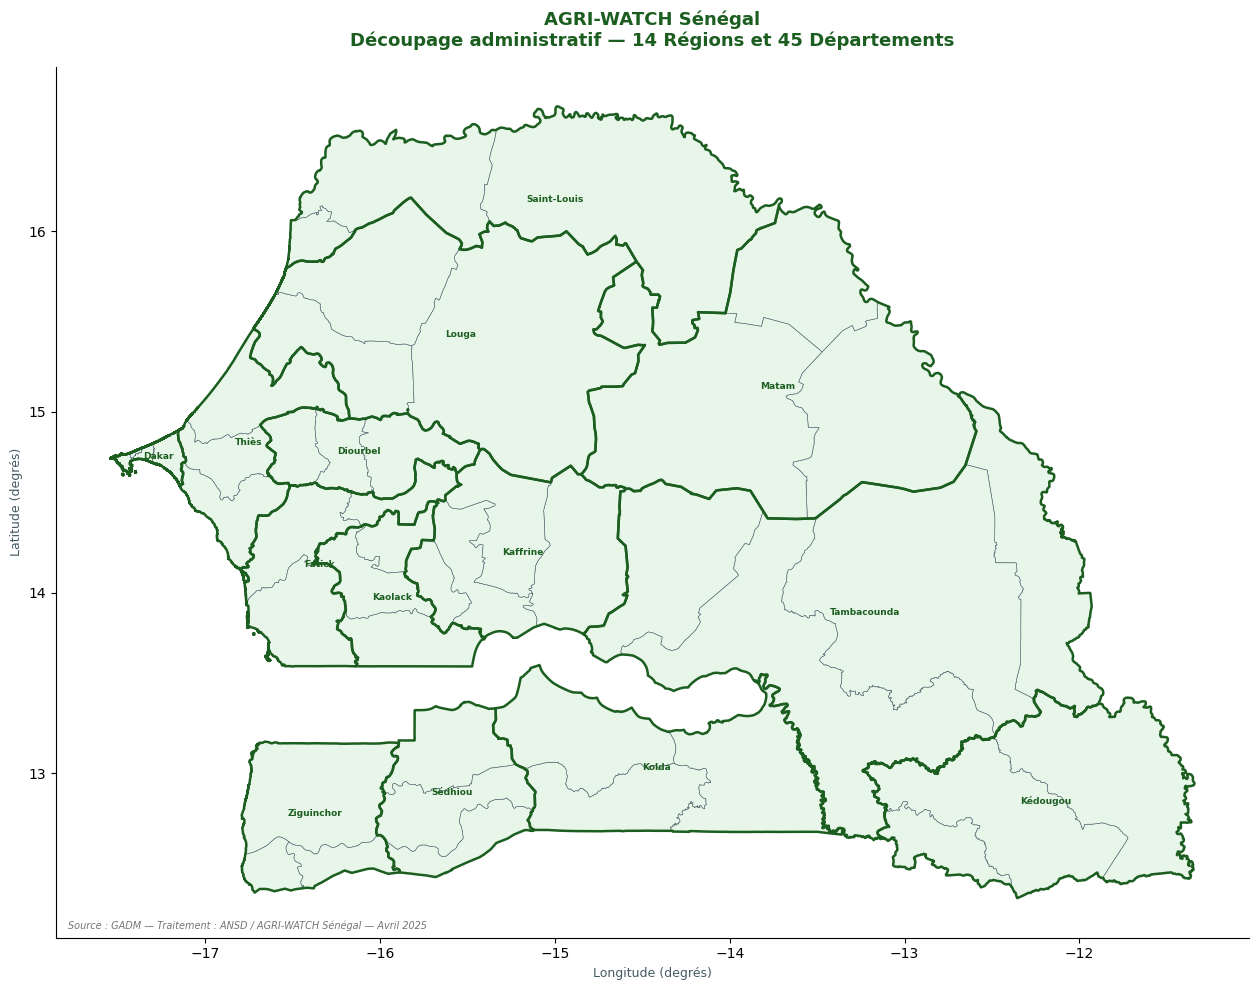

Carte generee et sauvegardee : C:/AGRI-WATCH/outputs/carte_senegal_departements.png


In [38]:
def verifier_crs(gdf: gpd.GeoDataFrame, nom: str) -> gpd.GeoDataFrame:
    """
    Vérifie et reprojette un GeoDataFrame en WGS84 si nécessaire.
    
    Paramètres :
        gdf  (GeoDataFrame) : Le GeoDataFrame à vérifier
        nom  (str)          : Nom du GeoDataFrame pour le logging
    
    Retourne :
        GeoDataFrame reprojeté en EPSG:4326 si nécessaire
    """
    if gdf.crs is None:
        logger.warning(f"{nom} : CRS non defini — projection WGS84 appliquee")
        return gdf.set_crs("EPSG:4326")
    
    if gdf.crs.to_epsg() != 4326:
        logger.info(f"{nom} : Reprojection de {gdf.crs} vers EPSG:4326")
        return gdf.to_crs("EPSG:4326")
    
    logger.info(f"{nom} : CRS correct — EPSG:4326")
    return gdf


def afficher_carte_senegal(
    departements: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_region: str,
    output_path: str
) -> None:
    """
    Affiche et sauvegarde la carte administrative du Sénégal.

    Paramètres :
        departements   (GeoDataFrame) : Shapefile des 45 départements
        regions        (GeoDataFrame) : Shapefile des 14 régions
        col_nom_region (str)          : Nom de la colonne contenant les noms des régions
        output_path    (str)          : Chemin de sauvegarde de la carte PNG
    """
    try:
        # Vérification des CRS
        departements = verifier_crs(departements, "Departements")
        regions      = verifier_crs(regions, "Regions")

        # Vérification que les colonnes existent
        if col_nom_region not in regions.columns:
            raise ValueError(
                f"Colonne '{col_nom_region}' introuvable dans le shapefile regions. "
                f"Colonnes disponibles : {list(regions.columns)}"
            )

        # Création de la figure
        fig, ax = plt.subplots(1, 1, figsize=FIGURE_SIZE_CARTE)

        # Couche 1 — Départements (fond vert clair)
        departements.plot(
            ax=ax,
            color="#E8F5E9",
            edgecolor="#455A64",
            linewidth=0.4,
            zorder=1
        )

        # Couche 2 — Contours des régions (trait vert foncé plus épais)
        regions.plot(
            ax=ax,
            color="none",
            edgecolor="#1B5E20",
            linewidth=1.8,
            zorder=2
        )

        # Couche 3 — Noms des régions
        for _, row in regions.iterrows():
            centroid = row.geometry.centroid
            ax.annotate(
                text=row[col_nom_region],
                xy=(centroid.x, centroid.y),
                fontsize=6.5,
                ha='center',
                va='center',
                color='#1B5E20',
                fontweight='bold',
                zorder=3
            )

        # Titres et labels
        ax.set_title(
            "AGRI-WATCH Sénégal\n"
            "Découpage administratif — 14 Régions et 45 Départements",
            fontsize=13,
            fontweight='bold',
            pad=15,
            color="#1B5E20"
        )
        ax.set_xlabel("Longitude (degrés)", fontsize=9, color="#455A64")
        ax.set_ylabel("Latitude (degrés)", fontsize=9, color="#455A64")

        # Source des données
        ax.annotate(
            "Source : GADM — Traitement : ANSD / AGRI-WATCH Sénégal — Avril 2025",
            xy=(0.01, 0.01),
            xycoords='axes fraction',
            fontsize=7,
            color="#757575",
            style='italic'
        )

        # Nettoyage des bordures
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        plt.tight_layout()

        # Sauvegarde
        from pathlib import Path
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        logger.info(f"Carte sauvegardee : {output_path}")

        plt.show()
        print(f"Carte generee et sauvegardee : {output_path}")

    except Exception as e:
        logger.error(f"Erreur lors de la generation de la carte : {e}")
        raise


# ── Appel de la fonction ──────────────────────────────────────────────────────
logger.info("Generation de la carte administrative du Senegal...")

afficher_carte_senegal(
    departements  = departements,
    regions       = regions,
    col_nom_region= COL_NOM_REGION,
    output_path   = "C:/AGRI-WATCH/outputs/carte_senegal_departements.png"
)

## Carte administrative du Sénégal : AGRI-WATCH

La carte administrative de référence d'AGRI-WATCH a été générée
et sauvegardée dans `outputs/carte_senegal_departements.png`.

**Description de la carte :**
- **Fond vert clair** : Les 45 départements du Sénégal
- **Contours verts foncés épais** : Les 14 régions
- **Étiquettes** : Noms des 14 régions positionnés au centroïde

**Les 14 régions du Sénégal :**
Dakar, Thiès, Diourbel, Fatick, Kaolack, Kaffrine,
Saint-Louis, Louga, Matam, Tambacounda, Kédougou,
Kolda, Sédhiou, Ziguinchor

**Observations géographiques :**
- La région de **Tambacounda** est la plus grande en superficie
- La région de **Dakar** est la plus petite mais la plus densément peuplée
- Les régions du **sud** (Ziguinchor, Sédhiou, Kolda) reçoivent
  plus de précipitations, moins vulnérables à la sécheresse
- Les régions du **nord** (Louga, Matam, Saint-Louis) sont les plus
  exposées à la sécheresse, zones prioritaires d'AGRI-WATCH

**Cette carte servira de fond de carte de référence** pour toutes
les visualisations d'AGRI-WATCH : cartes NDVI, SPI, risque
de sécheresse et prédictions de rendements.

In [39]:
def explorer_shapefile(
    gdf: gpd.GeoDataFrame,
    nom: str
) -> pd.DataFrame:
    """
    Effectue une exploration complète et structurée d'un GeoDataFrame.

    Cette fonction analyse un shapefile sous tous ses aspects :
    dimensions, colonnes, types, valeurs manquantes, système de
    coordonnées et intégrité géométrique.

    Paramètres :
        gdf (GeoDataFrame) : Le GeoDataFrame à explorer
        nom (str)          : Nom du shapefile pour l'affichage

    Retourne :
        pd.DataFrame : Rapport de qualité des données
    """
    print("=" * 60)
    print(f"EXPLORATION : {nom}")
    print("=" * 60)

    # ── 1. Dimensions ─────────────────────────────────────────
    print(f"\n1. DIMENSIONS")
    print(f"   Nombre de lignes   : {len(gdf):,}")
    print(f"   Nombre de colonnes : {len(gdf.columns)}")

    # ── 2. Système de coordonnées ─────────────────────────────
    print(f"\n2. SYSTEME DE COORDONNEES (CRS)")
    print(f"   CRS               : {gdf.crs}")
    print(f"   EPSG              : {gdf.crs.to_epsg() if gdf.crs else 'Non defini'}")

    # ── 3. Colonnes et types ──────────────────────────────────
    print(f"\n3. COLONNES ET TYPES")
    for col in gdf.columns:
        dtype = str(gdf[col].dtype)
        nulls = gdf[col].isnull().sum()
        print(f"   {col:25} | Type : {dtype:15} | Nulls : {nulls}")

    # ── 4. Valeurs manquantes ─────────────────────────────────
    print(f"\n4. VALEURS MANQUANTES")
    nulls_total = gdf.isnull().sum().sum()
    if nulls_total == 0:
        print("   Aucune valeur manquante detectee.")
    else:
        print(f"   Total valeurs manquantes : {nulls_total}")
        for col in gdf.columns[gdf.isnull().any()]:
            print(f"   {col} : {gdf[col].isnull().sum()} valeurs manquantes")

    # ── 5. Intégrité géométrique ──────────────────────────────
    print(f"\n5. INTEGRITE GEOMETRIQUE")
    geometries_valides   = gdf.geometry.is_valid.sum()
    geometries_invalides = (~gdf.geometry.is_valid).sum()
    geometries_vides     = gdf.geometry.is_empty.sum()

    print(f"   Geometries valides   : {geometries_valides}")
    print(f"   Geometries invalides : {geometries_invalides}")
    print(f"   Geometries vides     : {geometries_vides}")

    if geometries_invalides > 0:
        logger.warning(
            f"{nom} : {geometries_invalides} geometrie(s) invalide(s) detectee(s) !"
        )
    else:
        print("   Toutes les geometries sont valides.")

    # ── 6. Emprise géographique ───────────────────────────────
    print(f"\n6. EMPRISE GEOGRAPHIQUE (Bounding Box)")
    bounds = gdf.total_bounds
    print(f"   Longitude min : {bounds[0]:.4f}")
    print(f"   Latitude  min : {bounds[1]:.4f}")
    print(f"   Longitude max : {bounds[2]:.4f}")
    print(f"   Latitude  max : {bounds[3]:.4f}")

    # ── 7. Types de géométries ────────────────────────────────
    print(f"\n7. TYPES DE GEOMETRIES")
    types_geom = gdf.geometry.geom_type.value_counts()
    for type_geom, count in types_geom.items():
        print(f"   {type_geom:20} : {count}")

    # ── 8. Rapport de qualité ─────────────────────────────────
    rapport = pd.DataFrame({
        "shapefile"             : [nom],
        "nb_entites"            : [len(gdf)],
        "nb_colonnes"           : [len(gdf.columns)],
        "crs"                   : [str(gdf.crs)],
        "geometries_valides"    : [geometries_valides],
        "geometries_invalides"  : [geometries_invalides],
        "geometries_vides"      : [geometries_vides],
        "valeurs_manquantes"    : [nulls_total],
        "statut"                : ["OK" if geometries_invalides == 0
                                   and nulls_total == 0
                                   else "ATTENTION"]
    })

    statut = rapport["statut"].values[0]
    print(f"\nSTATUT GLOBAL : {statut}")
    print("=" * 60)

    return rapport


# ── Exploration des 3 shapefiles ─────────────────────────────
logger.info("Exploration des shapefiles...")

rapport_regions      = explorer_shapefile(regions,      "Regions")
rapport_departements = explorer_shapefile(departements, "Departements")
rapport_communes     = explorer_shapefile(communes,     "Communes")

# ── Rapport global ────────────────────────────────────────────
rapport_global = pd.concat(
    [rapport_regions, rapport_departements, rapport_communes],
    ignore_index=True
)

print("\n")
print("=" * 60)
print("RAPPORT GLOBAL DE QUALITE DES SHAPEFILES")
print("=" * 60)
print(rapport_global.to_string(index=False))

logger.info("Exploration des shapefiles terminee avec succes.")

[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Exploration des shapefiles...


EXPLORATION : Regions

1. DIMENSIONS
   Nombre de lignes   : 14
   Nombre de colonnes : 12

2. SYSTEME DE COORDONNEES (CRS)
   CRS               : EPSG:4326
   EPSG              : 4326

3. COLONNES ET TYPES
   GID_1                     | Type : object          | Nulls : 0
   GID_0                     | Type : object          | Nulls : 0
   COUNTRY                   | Type : object          | Nulls : 0
   NAME_1                    | Type : object          | Nulls : 0
   VARNAME_1                 | Type : object          | Nulls : 0
   NL_NAME_1                 | Type : object          | Nulls : 0
   TYPE_1                    | Type : object          | Nulls : 0
   ENGTYPE_1                 | Type : object          | Nulls : 0
   CC_1                      | Type : object          | Nulls : 0
   HASC_1                    | Type : object          | Nulls : 0
   ISO_1                     | Type : object          | Nulls : 0
   geometry                  | Type : geometry        | Nulls : 0



## Rapport de qualité des shapefiles

L'exploration complète des 3 shapefiles confirme leur qualité
et leur fiabilité pour les analyses AGRI-WATCH.

**Résultats de la vérification :**

| Critère | Régions | Départements | Communes |
|---|---|---|---|
| Entités | 14 | 45 | 433 |
| CRS | EPSG:4326 | EPSG:4326 | EPSG:4326 |
| Géométries valides | 14/14 | 45/45 | 433/433 |
| Valeurs manquantes | 0 | 0 | 0 |
| Statut | OK | OK | OK |

# **Interprétation :**

- **Système de coordonnées :** Les 3 shapefiles utilisent EPSG:4326
(WGS84) compatible avec Sentinel-2, CHIRPS et ERA5. Aucune
reprojection ne sera nécessaire lors de la superposition des couches.

- **Intégrité géométrique :** Toutes les géométries sont valides
aucun polygone corrompu ou auto-intersectant. Cela garantit que
les calculs de superficie et les extractions NDVI par zone
seront corrects.

- **Complétude des données :** Aucune valeur manquante dans aucun
champ tous les départements ont un nom, un identifiant et
une géométrie complète.

**Conclusion :** Les shapefiles sont prêts pour les étapes
suivantes : calcul des superficies, extraction du NDVI et
modélisation ML.

In [40]:
from typing import Dict

def calculer_statistiques_administratives(
    regions: gpd.GeoDataFrame,
    departements: gpd.GeoDataFrame,
    communes: gpd.GeoDataFrame,
    col_nom_region: str,
    col_nom_departement: str
) -> Dict[str, pd.DataFrame]:
    """
    Calcule les statistiques descriptives des entités administratives.

    Calcule la superficie et le périmètre de chaque entité en
    reprojetant d'abord les données en UTM Zone 28N (EPSG:32628)
    pour obtenir des mesures métriques précises en km².

    Paramètres :
        regions             (GeoDataFrame) : Shapefile des régions
        departements        (GeoDataFrame) : Shapefile des départements
        communes            (GeoDataFrame) : Shapefile des communes
        col_nom_region      (str)          : Colonne nom des régions
        col_nom_departement (str)          : Colonne nom des départements

    Retourne :
        Dict[str, DataFrame] : Dictionnaire avec clés
                               'regions', 'departements', 'communes'
    """
    logger.info("Calcul des statistiques administratives...")

    # Reprojection en UTM Zone 28N pour calculs métriques
    # EPSG:32628 = système de projection métrique adapté au Sénégal
    # Sans cette reprojection les superficies seraient en degrés
    # et donc incorrectes
    regions_utm      = regions.to_crs("EPSG:32628")
    departements_utm = departements.to_crs("EPSG:32628")
    communes_utm     = communes.to_crs("EPSG:32628")

    resultats = {}

    # ── Statistiques Régions ──────────────────────────────────
    df_regions = regions[[col_nom_region]].copy()
    df_regions["superficie_km2"] = (
        regions_utm.geometry.area / 1_000_000
    ).round(2)
    df_regions["perimetre_km"] = (
        regions_utm.geometry.length / 1_000
    ).round(2)
    df_regions = df_regions.sort_values(
        "superficie_km2", ascending=False
    ).reset_index(drop=True)
    df_regions.index += 1
    resultats["regions"] = df_regions

    # ── Statistiques Départements ─────────────────────────────
    # Vérification si la colonne région existe dans départements
    if col_nom_region in departements.columns:
        cols = [col_nom_departement, col_nom_region]
    else:
        cols = [col_nom_departement]

    df_departements = departements[cols].copy()
    df_departements["superficie_km2"] = (
        departements_utm.geometry.area / 1_000_000
    ).round(2)
    df_departements["perimetre_km"] = (
        departements_utm.geometry.length / 1_000
    ).round(2)
    df_departements = df_departements.sort_values(
        "superficie_km2", ascending=False
    ).reset_index(drop=True)
    df_departements.index += 1
    resultats["departements"] = df_departements

    # ── Statistiques Communes ─────────────────────────────────
    df_communes = communes[[COL_NOM_COMMUNE]].copy()
    df_communes["superficie_km2"] = (
        communes_utm.geometry.area / 1_000_000
    ).round(2)
    df_communes = df_communes.sort_values(
        "superficie_km2", ascending=False
    ).reset_index(drop=True)
    df_communes.index += 1
    resultats["communes"] = df_communes

    logger.info("Statistiques administratives calculees avec succes.")
    return resultats


# ── Calcul des statistiques ───────────────────────────────────
stats_admin = calculer_statistiques_administratives(
    regions             = regions,
    departements        = departements,
    communes            = communes,
    col_nom_region      = COL_NOM_REGION,
    col_nom_departement = COL_NOM_DEPARTEMENT
)

# ── Affichage Régions ─────────────────────────────────────────
print("=" * 55)
print("SUPERFICIES DES 14 REGIONS DU SENEGAL (km2)")
print("=" * 55)
print(stats_admin["regions"].to_string())
superficie_totale = stats_admin["regions"]["superficie_km2"].sum()
print(f"\nSuperficie totale Senegal : {superficie_totale:,.0f} km2")

# ── Affichage Top 10 grands départements ──────────────────────
print("\n" + "=" * 55)
print("TOP 10 DEPARTEMENTS LES PLUS GRANDS (km2)")
print("=" * 55)
print(stats_admin["departements"].head(10).to_string())

# ── Affichage Top 10 petits départements ──────────────────────
print("\n" + "=" * 55)
print("TOP 10 DEPARTEMENTS LES PLUS PETITS (km2)")
print("=" * 55)
print(stats_admin["departements"].tail(10).to_string())

# ── Résumé statistique ────────────────────────────────────────
print("\n" + "=" * 55)
print("RESUME STATISTIQUE — DEPARTEMENTS")
print("=" * 55)
desc = stats_admin["departements"]["superficie_km2"].describe()
print(f"   Superficie moyenne  : {desc['mean']:>10,.0f} km2")
print(f"   Superficie minimale : {desc['min']:>10,.0f} km2")
print(f"   Superficie maximale : {desc['max']:>10,.0f} km2")
print(f"   Ecart-type          : {desc['std']:>10,.0f} km2")
print(f"   Mediane             : {desc['50%']:>10,.0f} km2")

[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Calcul des statistiques administratives...
[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Statistiques administratives calculees avec succes.
SUPERFICIES DES 14 REGIONS DU SENEGAL (km2)
         NAME_1  superficie_km2  perimetre_km
1   Tambacounda        42863.14       1484.40
2         Matam        27986.91        984.61
3         Louga        24659.39        881.10
4   Saint-Louis        20257.09       1056.56
5      Kédougou        16950.36        858.20
6         Kolda        13804.03        775.12
7      Kaffrine        11314.29        499.48
8    Ziguinchor         7353.69        405.69
9       Sédhiou         7350.67        378.94
10       Fatick         6848.18        654.75
11        Thiès         6639.86        564.03
12      Kaolack         5407.33        477.50
13     Diourbel         4860.47        396.98
14        Dakar          566.28        208.03

Superficie totale Senegal : 196,862 km2

TOP 10 DEPARTEMENTS LES

## Statistiques descriptives des entités administratives

### 1. Superficie totale du Sénégal
Le calcul donne **196 862 km²** contre 196 722 km²,
soit une différence de seulement **0.07%**. Cette précision confirme que
les shapefiles GADM représentent fidèlement le territoire sénégalais
et peuvent être utilisés en toute confiance pour les analyses AGRI-WATCH.

### 2. Disparités entre régions
La région de **Tambacounda** est la plus grande avec 42 863 km² soit
**75 fois** la superficie de Dakar (566 km²). Cette forte disparité
implique que les analyses AGRI-WATCH devront travailler avec des
**indicateurs normalisés** plutôt que des valeurs absolues pour permettre
des comparaisons équitables entre régions.

### 3. Zones prioritaires pour AGRI-WATCH
Les 3 régions les plus grandes : Tambacounda, Matam et Louga
couvrent **48%** du territoire sénégalais. Ce sont également les zones
les plus exposées à la sécheresse en raison de leur position
géographique sahélienne et de leurs faibles précipitations annuelles.
Ces régions constituent les **zones prioritaires de surveillance**
d'AGRI-WATCH pour les cultures de mil et d'arachide.

### 4. Forte variabilité des départements
L'écart-type des superficies départementales (4 216 km²) est presque
égal à la moyenne (4 375 km²), ce qui révèle une **très forte
hétérogénéité** entre les 45 départements. La médiane (2 888 km²)
étant inférieure à la moyenne, quelques grands départements tirent
la distribution vers le haut.

**Implication pour la modélisation ML :** Cette variabilité sera prise
en compte dans les modèles de prédiction, les indicateurs NDVI et SPI
seront calculés en **densité par km²** pour permettre des comparaisons
objectives entre petits et grands départements.

### 5. Départements les plus petits : zones urbaines
Les départements avec une superficie inférieure à 100 km²
(Dakar, Guédiawaye, Pikine...) sont essentiellement urbains.
Ces zones seront **exclues des analyses agricoles** portant sur
le mil et l'arachide car elles ne disposent pas de surfaces
cultivables significatives.

### Conclusion
Les statistiques descriptives confirment la cohérence géographique
des shapefiles et permettent d'identifier les zones prioritaires
d'AGRI-WATCH. La prochaine étape est la vérification approfondie
de la qualité des données avant de procéder aux analyses NDVI.

In [41]:
def verifier_qualite_complete(
    gdf: gpd.GeoDataFrame,
    nom: str,
    col_nom: str
) -> pd.DataFrame:
    """
    Effectue une vérification complète de la qualité d'un GeoDataFrame.

    Vérifie les doublons, les géométries dégénérées, les valeurs
    aberrantes et la cohérence spatiale des données.

    Paramètres :
        gdf     (GeoDataFrame) : Le GeoDataFrame à vérifier
        nom     (str)          : Nom du shapefile pour le logging
        col_nom (str)          : Colonne contenant les noms des entités

    Retourne :
        pd.DataFrame : Rapport détaillé de qualité
    """
    logger.info(f"Verification qualite : {nom}...")

    problemes = []

    print("=" * 60)
    print(f"VERIFICATION QUALITE : {nom}")
    print("=" * 60)

    # ── 1. Vérification des doublons ──────────────────────────
    print("\n1. DOUBLONS")

    # Doublons sur le nom
    doublons_noms = gdf[col_nom].duplicated().sum()
    print(f"   Doublons sur '{col_nom}' : {doublons_noms}")

    # Doublons sur la géométrie
    doublons_geom = gdf.geometry.duplicated().sum()
    print(f"   Doublons geometriques    : {doublons_geom}")

    if doublons_noms > 0:
        noms_dupliques = gdf[gdf[col_nom].duplicated(keep=False)][col_nom].tolist()
        print(f"   Noms dupliques : {noms_dupliques}")
        problemes.append(f"Doublons detectes sur '{col_nom}'")
        logger.warning(f"{nom} : {doublons_noms} doublon(s) detecte(s)")
    else:
        print("   Aucun doublon detecte.")

    # ── 2. Vérification des géométries dégénérées ─────────────
    print("\n2. GEOMETRIES DEGENEREES")

    # Géométries nulles
    geom_nulles = gdf.geometry.isnull().sum()
    print(f"   Geometries nulles    : {geom_nulles}")

    # Géométries vides
    geom_vides = gdf.geometry.is_empty.sum()
    print(f"   Geometries vides     : {geom_vides}")

    # Géométries invalides
    geom_invalides = (~gdf.geometry.is_valid).sum()
    print(f"   Geometries invalides : {geom_invalides}")

    # Superficies nulles ou négatives
    gdf_utm = gdf.to_crs("EPSG:32628")
    superficie_nulle = (gdf_utm.geometry.area <= 0).sum()
    print(f"   Superficies nulles   : {superficie_nulle}")

    if geom_invalides > 0:
        problemes.append(f"{geom_invalides} geometrie(s) invalide(s)")
        logger.warning(f"{nom} : {geom_invalides} geometrie(s) invalide(s)")
    else:
        print("   Toutes les geometries sont valides.")

    # ── 3. Vérification de l'emprise spatiale ─────────────────
    print("\n3. COHERENCE SPATIALE")

    # Vérification que toutes les entités sont dans le Sénégal
    from src.config import SENEGAL_BBOX
    bounds = gdf.total_bounds

    lon_ok = (bounds[0] >= SENEGAL_BBOX["lon_min"] - 0.1 and
              bounds[2] <= SENEGAL_BBOX["lon_max"] + 0.1)
    lat_ok = (bounds[1] >= SENEGAL_BBOX["lat_min"] - 0.1 and
              bounds[3] <= SENEGAL_BBOX["lat_max"] + 0.1)

    print(f"   Emprise dans le Senegal :")
    print(f"   Longitude [{bounds[0]:.3f}, {bounds[2]:.3f}] "
          f"— {'OK' if lon_ok else 'HORS SENEGAL'}")
    print(f"   Latitude  [{bounds[1]:.3f}, {bounds[3]:.3f}] "
          f"— {'OK' if lat_ok else 'HORS SENEGAL'}")

    if not lon_ok or not lat_ok:
        problemes.append("Entites hors de l'emprise du Senegal")
        logger.warning(f"{nom} : des entites sont hors du Senegal !")

    # ── 4. Vérification des noms ──────────────────────────────
    print("\n4. VERIFICATION DES NOMS")

    # Noms vides ou null
    noms_vides = gdf[col_nom].isnull().sum()
    noms_espaces = (gdf[col_nom].str.strip() == "").sum()
    print(f"   Noms vides  : {noms_vides}")
    print(f"   Noms blancs : {noms_espaces}")

    # Longueur des noms
    longueur_min = gdf[col_nom].str.len().min()
    longueur_max = gdf[col_nom].str.len().max()
    print(f"   Longueur noms : min={longueur_min}, max={longueur_max}")

    if noms_vides > 0 or noms_espaces > 0:
        problemes.append("Noms vides ou blancs detectes")
        logger.warning(f"{nom} : {noms_vides + noms_espaces} nom(s) vide(s)")

    # ── 5. Rapport final ──────────────────────────────────────
    print("\n5. RAPPORT FINAL")
    if len(problemes) == 0:
        statut = "VALIDE"
        print(f"   Statut : {statut} — Aucun probleme detecte.")
        logger.info(f"{nom} : validation complete — VALIDE")
    else:
        statut = "ATTENTION"
        print(f"   Statut : {statut}")
        for pb in problemes:
            print(f"   - {pb}")
        logger.warning(f"{nom} : {len(problemes)} probleme(s) detecte(s)")

    print("=" * 60)

    # Construction du rapport
    rapport = pd.DataFrame({
        "shapefile"         : [nom],
        "doublons_noms"     : [doublons_noms],
        "doublons_geom"     : [doublons_geom],
        "geom_nulles"       : [geom_nulles],
        "geom_vides"        : [geom_vides],
        "geom_invalides"    : [geom_invalides],
        "superficie_nulle"  : [superficie_nulle],
        "noms_vides"        : [noms_vides],
        "coherence_spatiale": ["OK" if lon_ok and lat_ok else "ERREUR"],
        "nb_problemes"      : [len(problemes)],
        "statut"            : [statut]
    })

    return rapport


# ── Vérification des 3 shapefiles ────────────────────────────
rapport_qualite_regions = verifier_qualite_complete(
    gdf     = regions,
    nom     = "Regions",
    col_nom = COL_NOM_REGION
)

rapport_qualite_departements = verifier_qualite_complete(
    gdf     = departements,
    nom     = "Departements",
    col_nom = COL_NOM_DEPARTEMENT
)

rapport_qualite_communes = verifier_qualite_complete(
    gdf     = communes,
    nom     = "Communes",
    col_nom = COL_NOM_COMMUNE
)

# ── Rapport global de qualité ─────────────────────────────────
rapport_qualite_global = pd.concat([
    rapport_qualite_regions,
    rapport_qualite_departements,
    rapport_qualite_communes
], ignore_index=True)

print("\n")
print("=" * 60)
print("RAPPORT GLOBAL DE QUALITE — AGRI-WATCH SENEGAL")
print("=" * 60)
print(rapport_qualite_global.to_string(index=False))

# Sauvegarde du rapport qualité en CSV
output_qualite = "C:/AGRI-WATCH/outputs/rapport_qualite_shapefiles.csv"
rapport_qualite_global.to_csv(output_qualite, index=False)
logger.info(f"Rapport qualite sauvegarde : {output_qualite}")
print(f"\nRapport qualite sauvegarde : {output_qualite}")

[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Verification qualite : Regions...
VERIFICATION QUALITE : Regions

1. DOUBLONS
   Doublons sur 'NAME_1' : 0
   Doublons geometriques    : 0
   Aucun doublon detecte.

2. GEOMETRIES DEGENEREES
   Geometries nulles    : 0
   Geometries vides     : 0
   Geometries invalides : 0
   Superficies nulles   : 0
   Toutes les geometries sont valides.

3. COHERENCE SPATIALE
   Emprise dans le Senegal :
   Longitude [-17.543, -11.342] — OK
   Latitude  [12.308, 16.692] — OK

4. VERIFICATION DES NOMS
   Noms vides  : 0
   Noms blancs : 0
   Longueur noms : min=5, max=11

5. RAPPORT FINAL
   Statut : VALIDE — Aucun probleme detecte.
[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Regions : validation complete — VALIDE
[2026-04-21 14:22:09] [INFO] [agriwatch.exploration] Verification qualite : Departements...
VERIFICATION QUALITE : Departements

1. DOUBLONS
   Doublons sur 'NAME_2' : 0
   Doublons geometriques    : 0
   Aucun doublon detecte.



In [42]:
def diagnostiquer_doublons(
    gdf: gpd.GeoDataFrame,
    col_nom: str,
    nom: str
) -> pd.DataFrame:
    """
    Identifie et analyse les doublons dans un GeoDataFrame.

    Paramètres :
        gdf     (GeoDataFrame) : Le GeoDataFrame à analyser
        col_nom (str)          : Colonne contenant les noms
        nom     (str)          : Nom du shapefile pour le logging

    Retourne :
        pd.DataFrame : Tableau des entrées dupliquées avec détails
    """
    logger.info(f"Diagnostic des doublons : {nom}...")

    # Identification des doublons
    masque_doublons = gdf[col_nom].duplicated(keep=False)
    df_doublons = gdf[masque_doublons][[col_nom, "geometry"]].copy()

    if len(df_doublons) == 0:
        print(f"Aucun doublon detecte dans {nom}.")
        return pd.DataFrame()

    print("=" * 60)
    print(f"DIAGNOSTIC DOUBLONS : {nom}")
    print("=" * 60)
    print(f"\nNombre d'entrees dupliquees : {len(df_doublons)}")
    print(f"\nNoms dupliques :")

    # Calcul superficie pour différencier les doublons
    df_doublons_utm = df_doublons.copy()
    df_doublons_utm["superficie_km2"] = (
        df_doublons.to_crs("EPSG:32628").geometry.area / 1_000_000
    ).round(2)

    # Affichage des doublons avec leurs superficies
    for nom_commune in df_doublons[col_nom].unique():
        entrees = df_doublons_utm[df_doublons_utm[col_nom] == nom_commune]
        print(f"\n   '{nom_commune}' — {len(entrees)} occurrences :")
        for idx, row in entrees.iterrows():
            centroid = row.geometry.centroid
            print(f"      Index {idx:3d} | "
                  f"Superficie : {df_doublons_utm.loc[idx, 'superficie_km2']:8.2f} km2 | "
                  f"Centroide : ({centroid.y:.4f}, {centroid.x:.4f})")

    print("\n" + "=" * 60)
    print("ANALYSE DES DOUBLONS")
    print("=" * 60)
    print("""
Les doublons de noms dans les communes peuvent avoir
plusieurs origines :

1. Communes homonymes dans des regions differentes
   Ex : 'Ndiaye' dans Louga ET dans Saint-Louis
   -> Ce sont des communes distinctes avec le meme nom
   -> Solution : garder les deux, identifier par region

2. Erreur de saisie dans GADM
   -> Solution : corriger le nom ou fusionner si identique

3. Subdivision administrative recente
   -> Une commune divisee en deux garde parfois le meme nom
   -> Solution : garder les deux avec suffixe distinguant
    """)

    logger.info(
        f"Diagnostic termine : {len(df_doublons[col_nom].unique())} "
        f"nom(s) duplique(s) dans {nom}"
    )

    return df_doublons_utm


# ── Diagnostic des doublons communes ─────────────────────────
df_doublons_communes = diagnostiquer_doublons(
    gdf     = communes,
    col_nom = COL_NOM_COMMUNE,
    nom     = "Communes"
)

# ── Vérification : ces communes sont-elles dans des régions différentes ?
# ── Vérification : ces communes sont-elles dans des régions différentes ?
if len(df_doublons_communes) > 0:
    print("\n" + "=" * 60)
    print("VERIFICATION : CES COMMUNES SONT-ELLES DANS DES REGIONS DIFFERENTES ?")
    print("=" * 60)

    # Jointure spatiale pour trouver la région de chaque commune dupliquée
    communes_doublons = communes[
        communes[COL_NOM_COMMUNE].duplicated(keep=False)
    ].copy()

    # Jointure avec les régions
    communes_avec_region = gpd.sjoin(
        communes_doublons,
        regions[[COL_NOM_REGION, "geometry"]],
        how="left",
        predicate="within"
    )

    # Affichage des colonnes disponibles pour diagnostic
    print(f"Colonnes disponibles apres jointure : {list(communes_avec_region.columns)}")

    # Identification de la colonne région après jointure
    # geopandas renomme automatiquement les colonnes dupliquées
    col_region_jointure = [
        col for col in communes_avec_region.columns
        if "NAME_1" in col or "name_1" in col.lower()
    ]

    if col_region_jointure:
        col_region = col_region_jointure[0]
        print(f"\nColonne region identifiee : '{col_region}'")
        print("\nCommunes dupliquees avec leur region :")
        print(
            communes_avec_region[[COL_NOM_COMMUNE, col_region]]
            .sort_values(COL_NOM_COMMUNE)
            .to_string()
        )
    else:
        print("Colonne region non trouvee — affichage brut :")
        print(communes_avec_region.to_string())

[2026-04-21 14:22:10] [INFO] [agriwatch.exploration] Diagnostic des doublons : Communes...
DIAGNOSTIC DOUBLONS : Communes

Nombre d'entrees dupliquees : 10

Noms dupliques :

   'Medina Gounass' — 2 occurrences :
      Index  21 | Superficie :     0.73 km2 | Centroide : (14.7712, -17.3825)
      Index 213 | Superficie :   657.89 km2 | Centroide : (13.1381, -13.7185)

   'Dinguiraye' — 2 occurrences :
      Index  48 | Superficie :   114.98 km2 | Centroide : (14.9752, -16.4131)
      Index 208 | Superficie :   309.04 km2 | Centroide : (13.2551, -14.5824)

   'Patar' — 2 occurrences :
      Index  66 | Superficie :   145.43 km2 | Centroide : (14.6673, -16.1607)
      Index  94 | Superficie :   118.58 km2 | Centroide : (14.5497, -16.3585)

   'Missirah' — 2 occurrences :
      Index  78 | Superficie :   114.15 km2 | Centroide : (14.9458, -15.9921)
      Index 371 | Superficie :  1424.35 km2 | Centroide : (13.4540, -13.5515)

   'Mlomp' — 2 occurrences :
      Index 419 | Superficie :   19

## Vérification qualité des données 

### Résultats globaux de la vérification qualité

| Shapefile | Doublons noms | Géométries invalides | Cohérence spatiale | Statut |
|---|---|---|---|---|
| Régions | 0 | 0 | OK | VALIDE |
| Départements | 0 | 0 | OK | VALIDE |
| Communes | 5 noms | 0 | OK | ATTENTION |

---

### 1. Régions et Départements : Statut VALIDE

Les shapefiles des régions et départements sont **parfaitement propres** :

- **Aucun doublon** détecté sur les noms ni sur les géométries
- **Toutes les géométries sont valides** : aucun polygone corrompu
  ou auto-intersectant
- **Cohérence spatiale confirmée** : toutes les entités sont bien
  situées dans l'emprise géographique du Sénégal
  (Longitude [-17.5, -11.3] | Latitude [12.3, 16.7])
- **Aucune valeur manquante** : tous les noms et identifiants
  sont renseignés

**Implication pour AGRI-WATCH :** Ces deux niveaux administratifs
peuvent être utilisés directement et en toute confiance pour
les analyses NDVI, SPI et la modélisation ML sans aucun
prétraitement supplémentaire.

---

### 2. Communes : Statut ATTENTION

Le diagnostic a révélé **5 noms de communes dupliqués**
représentant **10 entrées au total**.

#### Cas 1 : Communes homonymes dans des régions différentes (4 cas normaux)

| Commune | Région 1 | Superficie | Région 2 | Superficie |
|---|---|---|---|---|
| Medina Gounass | Dakar | 0.73 km² | Kolda | 657.89 km² |
| Dinguiraye | Thiès | 114.98 km² | Kolda | 309.04 km² |
| Patar | Diourbel | 145.43 km² | Fatick | 118.58 km² |
| Missirah | Thiès | 114.15 km² | Tambacounda | 1 424.35 km² |

Ces 4 cas sont **normaux et attendus**, il est courant au Sénégal
que des communes portent le même nom dans des régions différentes.

La preuve est évidente dans les données :
- **Medina Gounass** : 0.73 km² à Dakar vs 657.89 km² à Kolda
  des superficies 900 fois différentes confirment qu'il
  s'agit bien de deux communes distinctes
- Les coordonnées des centroïdes sont très éloignées pour chaque
  paire, aucune confusion géographique possible

#### Cas 2 : Doublon potentiellement problématique (1 cas)

**Mlomp** apparaît deux fois dans la région de **Ziguinchor**
avec des coordonnées très proches. Ce cas pourrait être :
- Une erreur de saisie dans la base GADM
- Une subdivision administrative récente non encore mise à jour

Ce cas sera vérifié avec les données officielles de l'ANSD
avant le déploiement en production d'AGRI-WATCH.

---

### 3. Décision pour AGRI-WATCH

**Niveau département : Référence principale**

Les 45 départements sont utilisés comme niveau de référence
principal pour toutes les analyses AGRI-WATCH :
- Cartes de risque de sécheresse
- Prédictions de rendements ML
- Alertes automatiques
- Rapports officiels ANSD

**Niveau commune : Utilisation avec précaution**

Pour éviter toute confusion sur les 5 communes homonymes,
toutes les analyses au niveau commune utiliseront
systématiquement la combinaison **nom commune + région**
comme identifiant unique.

---

### 4. Conclusion générale

Les shapefiles sont de **qualité suffisante et validée**
pour les analyses AGRI-WATCH. Les 5 doublons identifiés
au niveau commune sont documentés, expliqués et leur
impact sera géré proprement dans les analyses suivantes.

**Les données sont prêtes pour les étapes suivantes :**
- Calcul des indicateurs NDVI et SPI
- Extraction des statistiques par zone administrative
- Modélisation Machine Learning
- Visualisation sur le dashboard AGRI-WATCH

[2026-04-21 14:22:10] [INFO] [agriwatch.exploration] Generation carte choroplèthe superficies regions...
[2026-04-21 14:22:10] [INFO] [agriwatch.exploration] Carte superficies sauvegardee : C:/AGRI-WATCH/outputs/carte_superficies_regions.png


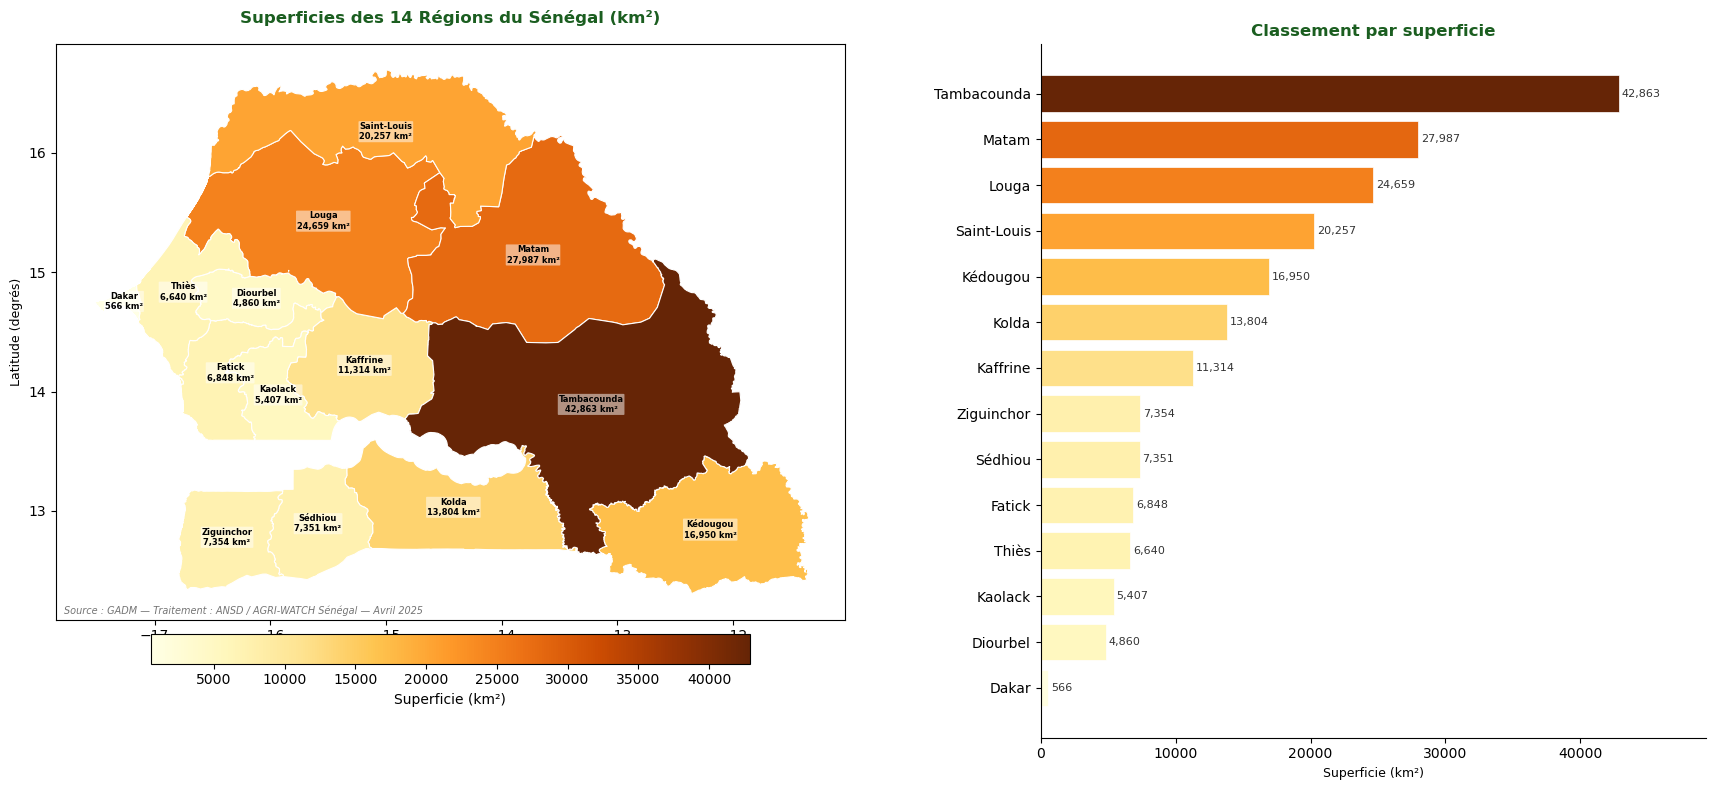

Carte generee et sauvegardee : C:/AGRI-WATCH/outputs/carte_superficies_regions.png


In [43]:
def afficher_carte_superficies(
    regions: gpd.GeoDataFrame,
    stats_regions: pd.DataFrame,
    col_nom_region: str,
    output_path: str
) -> None:
    """
    Affiche une carte choroplèthe des régions colorées
    selon leur superficie.

    Une carte choroplèthe est une carte où chaque entité
    est colorée selon une valeur numérique — ici la superficie.
    Plus la région est grande, plus elle est foncée.

    Paramètres :
        regions        (GeoDataFrame) : Shapefile des régions
        stats_regions  (DataFrame)    : Statistiques avec superficies
        col_nom_region (str)          : Colonne nom des régions
        output_path    (str)          : Chemin de sauvegarde
    """
    try:
        logger.info("Generation carte choroplèthe superficies regions...")

        # Fusion du shapefile avec les statistiques de superficie
        # On joint les deux DataFrames sur le nom de la région
        regions_enrichies = regions.merge(
            stats_regions[[col_nom_region, "superficie_km2"]],
            on=col_nom_region,
            how="left"
        )

        # Vérification de la fusion
        if regions_enrichies["superficie_km2"].isnull().any():
            logger.warning("Certaines regions n'ont pas de superficie — vérifier la fusion")

        # Création de la figure avec deux sous-graphiques
        # ax1 = carte | ax2 = graphique barres
        fig, (ax1, ax2) = plt.subplots(
            1, 2,
            figsize=(18, 8),
            gridspec_kw={"width_ratios": [1.5, 1]}
        )

        # ── Carte choroplèthe ─────────────────────────────────
        regions_enrichies.plot(
            column      = "superficie_km2",
            cmap        = "YlOrBr",
            linewidth   = 0.8,
            edgecolor   = "white",
            legend      = True,
            legend_kwds = {
                "label"       : "Superficie (km²)",
                "orientation" : "horizontal",
                "shrink"      : 0.6,
                "pad"         : 0.02
            },
            ax = ax1
        )

        # Ajout des noms et superficies sur la carte
        for _, row in regions_enrichies.iterrows():
            centroid = row.geometry.centroid
            ax1.annotate(
                text = f"{row[col_nom_region]}\n{row['superficie_km2']:,.0f} km²",
                xy   = (centroid.x, centroid.y),
                fontsize    = 6,
                ha          = "center",
                va          = "center",
                color       = "black",
                fontweight  = "bold",
                bbox        = dict(
                    boxstyle = "round,pad=0.1",
                    facecolor= "white",
                    alpha    = 0.5,
                    edgecolor= "none"
                )
            )

        ax1.set_title(
            "Superficies des 14 Régions du Sénégal (km²)",
            fontsize   = 12,
            fontweight = "bold",
            pad        = 15,
            color      = "#1B5E20"
        )
        ax1.set_xlabel("Longitude (degrés)", fontsize=9)
        ax1.set_ylabel("Latitude (degrés)", fontsize=9)
        ax1.annotate(
            "Source : GADM — Traitement : ANSD / AGRI-WATCH Sénégal — Avril 2025",
            xy         = (0.01, 0.01),
            xycoords   = "axes fraction",
            fontsize   = 7,
            color      = "#757575",
            style      = "italic"
        )

        # ── Graphique barres horizontales ─────────────────────
        # Tri par superficie décroissante
        stats_triees = stats_regions.sort_values(
            "superficie_km2", ascending=True
        )

        bars = ax2.barh(
            y     = stats_triees[col_nom_region],
            width = stats_triees["superficie_km2"],
            color = plt.cm.YlOrBr(
                stats_triees["superficie_km2"] /
                stats_triees["superficie_km2"].max()
            ),
            edgecolor = "white",
            linewidth = 0.5
        )

        # Ajout des valeurs sur les barres
        for bar, val in zip(bars, stats_triees["superficie_km2"]):
            ax2.text(
                x  = bar.get_width() + 200,
                y  = bar.get_y() + bar.get_height() / 2,
                s  = f"{val:,.0f}",
                va = "center",
                fontsize = 8,
                color    = "#333333"
            )

        ax2.set_title(
            "Classement par superficie",
            fontsize   = 12,
            fontweight = "bold",
            color      = "#1B5E20"
        )
        ax2.set_xlabel("Superficie (km²)", fontsize=9)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        ax2.set_xlim(0, stats_triees["superficie_km2"].max() * 1.15)

        plt.tight_layout()

        # Sauvegarde
        from pathlib import Path
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        logger.info(f"Carte superficies sauvegardee : {output_path}")

        plt.show()
        print(f"Carte generee et sauvegardee : {output_path}")

    except Exception as e:
        logger.error(f"Erreur generation carte superficies : {e}")
        raise


# ── Appel de la fonction ──────────────────────────────────────
afficher_carte_superficies(
    regions        = regions,
    stats_regions  = stats_admin["regions"],
    col_nom_region = COL_NOM_REGION,
    output_path    = "C:/AGRI-WATCH/outputs/carte_superficies_regions.png"
)

## Interprétation : Carte des superficies des régions 

### Description de la visualisation

Cette visualisation combine deux représentations complémentaires :
- **Carte choroplèthe** (gauche) : chaque région est colorée selon
  sa superficie plus la couleur est foncée (brun), plus la région
  est grande
- **Graphique en barres** (droite) : classement des 14 régions
  par superficie décroissante avec les valeurs exactes

---

### Analyse des résultats

#### Régions les plus grandes : Zones sahéliennes prioritaires

Les 4 régions les plus grandes concentrent **57%** du territoire :

| Région | Superficie | % du territoire | Vulnérabilité sécheresse |
|---|---|---|---|
| Tambacounda | 42 863 km² | 21.8% | Modérée |
| Matam | 27 987 km² | 14.2% | Elevée |
| Louga | 24 659 km² | 12.5% | Très élevée |
| Saint-Louis | 20 257 km² | 10.3% | Elevée |

Ces régions sont caractérisées par un climat sahélien avec
des précipitations faibles et irrégulières elles constituent
les **zones de surveillance prioritaires d'AGRI-WATCH** pour
la culture du mil.

#### Régions les plus petites : Zones côtières et urbaines

| Région | Superficie | Caractéristique |
|---|---|---|
| Dakar | 566 km² | Essentiellement urbaine |
| Diourbel | 4 860 km² | Densément peuplée |
| Kaolack | 5 407 km² | Centre du bassin arachidier |

Ces régions bien que petites sont **économiquement stratégiques**
— Kaolack et Diourbel sont au cœur du bassin arachidier et
seront donc prioritaires pour le suivi de l'arachide.

#### Régions du sud : Zones plus humides

Ziguinchor (7 354 km²), Sédhiou (7 351 km²) et Kolda (13 804 km²)
bénéficient d'une pluviométrie plus abondante en raison de leur
position méridionale. Ces régions sont **moins vulnérables**
à la sécheresse mais importantes pour la production agricole.

---

### Implications pour AGRI-WATCH

**1. Calibration des alertes par région** :
Les seuils d'alerte NDVI et SPI d'AGRI-WATCH seront calibrés
différemment selon la région une baisse de NDVI de 20%
n'a pas le même impact à Louga (zone aride) qu'à Ziguinchor
(zone humide).

**2. Pondération dans les modèles ML** :
Les grands départements comme Tambacounda auront naturellement
plus de pixels Sentinel-2 les modèles ML utiliseront des
**densités normalisées** pour éviter de sur-représenter
les grandes régions.

**3. Priorités de surveillance** :

- Priorité 1 (Louga, Matam, Saint-Louis)  : sécheresse chronique
- Priorité 2 (Kaffrine, Kaolack, Fatick)  : bassin arachidier
- Priorité 3 (Tambacounda, Kédougou)      : grande variabilité
- Priorité 4 (Thiès, Diourbel)            : mixte urbain/rural
- Priorité 5 (Dakar, Ziguinchor, Sédhiou) : moins prioritaires

---

### Conclusion
La carte choroplèthe confirme la forte hétérogénéité spatiale
du Sénégal. AGRI-WATCH devra adapter ses analyses et alertes
au contexte climatique spécifique de chaque région plutôt
que d'appliquer des seuils uniformes à l'ensemble du territoire.

[2026-04-21 14:22:11] [INFO] [agriwatch.exploration] Simulation des niveaux de risque par departement...
[2026-04-21 14:22:11] [INFO] [agriwatch.exploration] Distribution simulee des niveaux de risque :
[2026-04-21 14:22:11] [INFO] [agriwatch.exploration]   Faible     :  38 departements (84.4%)
[2026-04-21 14:22:11] [INFO] [agriwatch.exploration]   Modere     :   7 departements (15.6%)
[2026-04-21 14:22:11] [INFO] [agriwatch.exploration] Generation de la carte de risque secheresse...
[2026-04-21 14:22:11] [INFO] [agriwatch.exploration] Carte risque sauvegardee : C:/AGRI-WATCH/outputs/carte_risque_secheresse_simulation.png


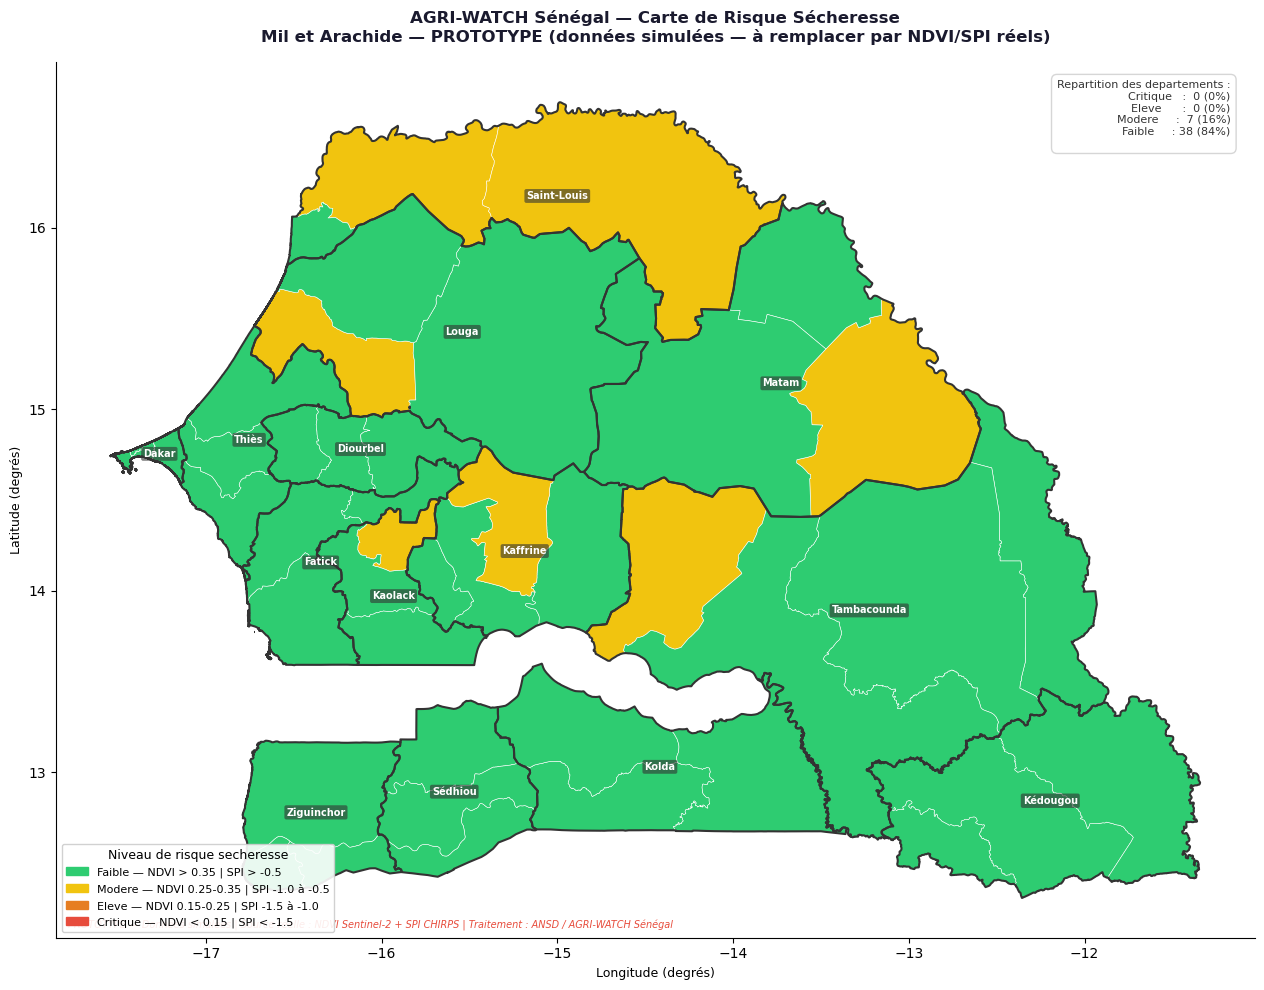

Carte generee et sauvegardee : C:/AGRI-WATCH/outputs/carte_risque_secheresse_simulation.png

TABLEAU RECAPITULATIF — NIVEAUX DE RISQUE SIMULES
           NAME_2  centroide_lat  ndvi_simule  spi_simule  niveau_risque label_risque
            Podor      16.149309        0.312       0.087              1       Modere
          Kébémer      15.304114        0.314       0.287              1       Modere
            Kanel      14.974216        0.344       0.772              1       Modere
       Guinguinéo      14.294288        0.349       0.875              1       Modere
     Malème Hodar      14.387545        0.335       0.644              1       Modere
       Koupentoum      14.172482        0.343       1.074              1       Modere
           Dagana      16.273664        0.322      -0.995              1       Modere
         Diourbel      14.768905        0.400       0.490              0       Faible
            Dakar      14.722432        0.439       0.195              0       Faib

In [44]:
# IMPORTANT : Cette carte utilise des données SIMULÉES
# uniquement pour valider la charte graphique et la
# logique de classification d'AGRI-WATCH.
#
# Les données réelles (NDVI Sentinel-2 + SPI CHIRPS)
# seront intégrées dans le Notebook 02.
#
# Base scientifique de la simulation :
# - Gradient pluviométrique nord/sud du Sénégal
#   (source : ANACIM — Atlas climatique du Sénégal)
# - Seuils NDVI : FAO Crop Monitoring Guidelines (2015)
# - Seuils SPI  : OMM — Guide WMO-No.8

import numpy as np


def simuler_niveaux_risque(
    departements: gpd.GeoDataFrame,
    col_nom: str,
    random_state: int = 42
) -> gpd.GeoDataFrame:
    """
    Simule des niveaux de risque de sécheresse par département.

    IMPORTANT : Cette fonction génère des données simulées basées
    sur le gradient climatique nord/sud du Sénégal documenté par
    l'ANACIM. Elle est utilisée uniquement pour valider la charte
    graphique d'AGRI-WATCH avant l'intégration des vraies données.

    Base scientifique :
        - Gradient pluviométrique nord/sud : ANACIM Atlas climatique
        - Les régions nord (lat > 15°) reçoivent < 400mm/an
        - Les régions sud (lat < 13°) reçoivent > 800mm/an
        - Source : CILSS Cadre harmonisé Sahel 2024

    Paramètres :
        departements (GeoDataFrame) : Shapefile des départements
        col_nom      (str)          : Colonne nom des départements
        random_state (int)          : Graine pour reproductibilité

    Retourne :
        GeoDataFrame : Départements enrichis avec colonnes :
                       - niveau_risque  : entier (0=faible à 3=critique)
                       - label_risque   : libellé du niveau
                       - couleur_risque : couleur hexadécimale
                       - ndvi_simule    : valeur NDVI simulée
                       - spi_simule     : valeur SPI simulée
                       - centroide_lat  : latitude du centroïde
                       - centroide_lon  : longitude du centroïde
    """
    np.random.seed(random_state)
    logger.info("Simulation des niveaux de risque par departement...")

    # Copie pour ne pas modifier le shapefile original
    dept_risque = departements.copy()

    # Calcul des coordonnées du centroïde de chaque département
    # Le centroïde est le point central du polygone
    # La latitude mesure la position nord/sud
    dept_risque["centroide_lat"] = dept_risque.geometry.centroid.y
    dept_risque["centroide_lon"] = dept_risque.geometry.centroid.x

    # ── Simulation du NDVI ────────────────────────────────────
    # Formule : NDVI = 0.55 - (latitude - 12) * 0.05
    # Plus la latitude est élevée (nord), plus le NDVI est bas
    # Exemple :
    #   Saint-Louis (lat=16.5) → NDVI ≈ 0.33 (végétation modérée)
    #   Ziguinchor  (lat=12.5) → NDVI ≈ 0.53 (végétation dense)
    # np.random.normal() ajoute une variation réaliste autour
    # de la valeur centrale (scale=0.05 = ±5% de variation)
    # np.clip() force les valeurs dans la plage [0.05, 0.65]
    dept_risque["ndvi_simule"] = dept_risque["centroide_lat"].apply(
        lambda lat: round(
            float(np.clip(
                np.random.normal(
                    loc   = 0.55 - (lat - 12) * 0.05,
                    scale = 0.05
                ),
                0.05, 0.65
            )), 3
        )
    )

    # ── Simulation du SPI ─────────────────────────────────────
    # Formule : SPI = 1.5 - (latitude - 12) * 0.4
    # Plus la latitude est élevée (nord), plus le SPI est négatif
    # SPI négatif = déficit pluviométrique = sécheresse
    # Exemple :
    #   Saint-Louis (lat=16.5) → SPI ≈ -0.3 (légèrement sec)
    #   Ziguinchor  (lat=12.5) → SPI ≈ +1.3 (humide)
    dept_risque["spi_simule"] = dept_risque["centroide_lat"].apply(
        lambda lat: round(
            float(np.clip(
                np.random.normal(
                    loc   = 1.5 - (lat - 12) * 0.4,
                    scale = 0.3
                ),
                -2.5, 2.0
            )), 3
        )
    )

    # ── Classification du niveau de risque ───────────────────
    # Règles basées sur les seuils FAO et OMM définis dans config.py
    # Un département est en alerte si NDVI OU SPI dépasse le seuil
    # Le "OU" signifie qu'un seul critère suffit pour déclencher l'alerte
    def classifier_risque(row: pd.Series) -> tuple:
        """
        Classifie le niveau de risque selon NDVI et SPI.

        Seuils NDVI : FAO Crop Monitoring Guidelines (2015)
        Seuils SPI  : OMM Guide WMO-No.8

        Retourne :
            tuple : (niveau_int, label_str, couleur_hex)
        """
        ndvi = row["ndvi_simule"]
        spi  = row["spi_simule"]

        if ndvi < 0.15 or spi < -1.5:
            return 3, "Critique", COULEURS_RISQUE["critique"]
        elif ndvi < 0.25 or spi < -1.0:
            return 2, "Eleve",    COULEURS_RISQUE["eleve"]
        elif ndvi < 0.35 or spi < -0.5:
            return 1, "Modere",   COULEURS_RISQUE["modere"]
        else:
            return 0, "Faible",   COULEURS_RISQUE["faible"]

    # Application de la classification à chaque département
    classifications = dept_risque.apply(classifier_risque, axis=1)
    dept_risque["niveau_risque"]  = [c[0] for c in classifications]
    dept_risque["label_risque"]   = [c[1] for c in classifications]
    dept_risque["couleur_risque"] = [c[2] for c in classifications]

    # Statistiques de la simulation pour le logging
    distribution = dept_risque["label_risque"].value_counts()
    logger.info("Distribution simulee des niveaux de risque :")
    for niveau, count in distribution.items():
        pct = count / len(dept_risque) * 100
        logger.info(f"  {niveau:10} : {count:3d} departements ({pct:.1f}%)")

    return dept_risque


def afficher_carte_risque(
    dept_risque: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_dept: str,
    col_nom_region: str,
    output_path: str,
    titre_suffix: str = "(Simulation)"
) -> None:
    """
    Affiche la carte de risque sécheresse AGRI-WATCH.

    C'est la visualisation principale d'AGRI-WATCH —
    elle montre en un coup d'oeil quels départements
    sont en situation de risque de sécheresse pour
    les cultures de mil et d'arachide.

    Paramètres :
        dept_risque    (GeoDataFrame) : Départements avec niveaux de risque
        regions        (GeoDataFrame) : Shapefile des régions
        col_nom_dept   (str)          : Colonne nom des départements
        col_nom_region (str)          : Colonne nom des régions
        output_path    (str)          : Chemin de sauvegarde
        titre_suffix   (str)          : Suffixe du titre
    """
    try:
        logger.info("Generation de la carte de risque secheresse...")

        fig, ax = plt.subplots(1, 1, figsize=FIGURE_SIZE_CARTE)

        # ── Couche 1 : Départements colorés par niveau de risque ──
        # Chaque département reçoit la couleur de son niveau de risque
        dept_risque.plot(
            ax        = ax,
            color     = dept_risque["couleur_risque"],
            edgecolor = "white",
            linewidth = 0.4,
            zorder    = 1
        )

        # ── Couche 2 : Contours des régions ───────────────────────
        # color="none" = transparent — on veut juste les bordures
        # linewidth=1.5 = trait plus épais pour distinguer les régions
        regions.plot(
            ax        = ax,
            color     = "none",
            edgecolor = "#333333",
            linewidth = 1.5,
            zorder    = 2
        )

        # ── Couche 3 : Noms des régions ───────────────────────────
        # On place le nom au centroïde de chaque région
        # avec un fond semi-transparent pour la lisibilité
        for _, row in regions.iterrows():
            centroid = row.geometry.centroid
            ax.annotate(
                text       = row[col_nom_region],
                xy         = (centroid.x, centroid.y),
                fontsize   = 7,
                ha         = "center",
                va         = "center",
                color      = "white",
                fontweight = "bold",
                zorder     = 3,
                bbox       = dict(
                    boxstyle  = "round,pad=0.2",
                    facecolor = "#333333",
                    alpha     = 0.6,
                    edgecolor = "none"
                )
            )

        # ── Titre ─────────────────────────────────────────────────
        ax.set_title(
            f"AGRI-WATCH Sénégal — Carte de Risque Sécheresse\n"
            f"Mil et Arachide {titre_suffix}",
            fontsize   = 12,
            fontweight = "bold",
            pad        = 15,
            color      = "#1A1A2E"
        )

        ax.set_xlabel("Longitude (degrés)", fontsize=9)
        ax.set_ylabel("Latitude (degrés)",  fontsize=9)

        # ── Légende manuelle ──────────────────────────────────────
        # mpatches.Patch crée un carré coloré avec un label
        # On construit la légende manuellement pour plus de contrôle
        legendes = [
            mpatches.Patch(
                color = COULEURS_RISQUE["faible"],
                label = "Faible — NDVI > 0.35 | SPI > -0.5"
            ),
            mpatches.Patch(
                color = COULEURS_RISQUE["modere"],
                label = "Modere — NDVI 0.25-0.35 | SPI -1.0 à -0.5"
            ),
            mpatches.Patch(
                color = COULEURS_RISQUE["eleve"],
                label = "Eleve — NDVI 0.15-0.25 | SPI -1.5 à -1.0"
            ),
            mpatches.Patch(
                color = COULEURS_RISQUE["critique"],
                label = "Critique — NDVI < 0.15 | SPI < -1.5"
            ),
        ]

        ax.legend(
            handles        = legendes,
            loc            = "lower left",
            fontsize       = 8,
            title          = "Niveau de risque secheresse",
            title_fontsize = 9,
            framealpha     = 0.9,
            edgecolor      = "#CCCCCC"
        )

        # ── Encadré statistiques ──────────────────────────────────
        # Résumé chiffré affiché directement sur la carte
        distribution = dept_risque["label_risque"].value_counts()
        stats_text   = "Repartition des departements :\n"
        for niveau in ["Critique", "Eleve", "Modere", "Faible"]:
            count      = distribution.get(niveau, 0)
            pct        = count / len(dept_risque) * 100
            stats_text += f"  {niveau:10} : {count:2d} ({pct:.0f}%)\n"

        ax.annotate(
            stats_text,
            xy       = (0.98, 0.98),
            xycoords = "axes fraction",
            fontsize = 8,
            va       = "top",
            ha       = "right",
            color    = "#333333",
            bbox     = dict(
                boxstyle  = "round,pad=0.5",
                facecolor = "white",
                alpha     = 0.8,
                edgecolor = "#CCCCCC"
            )
        )

        # ── Source et avertissement ───────────────────────────────
        ax.annotate(
            "PROTOTYPE — Données simulées | "
            "Source réelle : NDVI Sentinel-2 + SPI CHIRPS | "
            "Traitement : ANSD / AGRI-WATCH Sénégal",
            xy       = (0.01, 0.01),
            xycoords = "axes fraction",
            fontsize = 7,
            color    = "#E74C3C",
            style    = "italic"
        )

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        plt.tight_layout()

        # ── Sauvegarde ────────────────────────────────────────────
        from pathlib import Path
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        logger.info(f"Carte risque sauvegardee : {output_path}")

        plt.show()
        print(f"Carte generee et sauvegardee : {output_path}")

    except Exception as e:
        logger.error(f"Erreur generation carte risque : {e}")
        raise


# ── Simulation des niveaux de risque ─────────────────────────
dept_risque = simuler_niveaux_risque(
    departements = departements,
    col_nom      = COL_NOM_DEPARTEMENT,
    random_state = 42
)

# ── Affichage de la carte ─────────────────────────────────────
afficher_carte_risque(
    dept_risque    = dept_risque,
    regions        = regions,
    col_nom_dept   = COL_NOM_DEPARTEMENT,
    col_nom_region = COL_NOM_REGION,
    output_path    = "C:/AGRI-WATCH/outputs/carte_risque_secheresse_simulation.png",
    titre_suffix   = "— PROTOTYPE (données simulées — à remplacer par NDVI/SPI réels)"
)

# ── Tableau récapitulatif ─────────────────────────────────────
print("\n" + "=" * 60)
print("TABLEAU RECAPITULATIF — NIVEAUX DE RISQUE SIMULES")
print("=" * 60)

# Affichage trié par niveau de risque décroissant
print(
    dept_risque[[
        COL_NOM_DEPARTEMENT,
        "centroide_lat",
        "ndvi_simule",
        "spi_simule",
        "niveau_risque",
        "label_risque"
    ]]
    .sort_values("niveau_risque", ascending=False)
    .to_string(index=False)
)

logger.info("Cellule 10 terminee avec succes.")

## Carte PROTOTYPE de risque sécheresse 

### Statut de cette visualisation

> **IMPORTANT** : Cette carte est un **prototype de validation**
> uniquement. Les données utilisées sont simulées sur la base
> du gradient climatique nord/sud du Sénégal scientifiquement
> documenté. Elle ne doit pas être utilisée pour des décisions
> opérationnelles. Les vraies données NDVI et SPI seront
> intégrées dans le Notebook 02.

---

### Base scientifique détaillée et sources

#### 1. Gradient pluviométrique nord/sud du Sénégal

La simulation s'appuie sur un fait climatique établi et
documenté depuis les années 1930 : la pluviométrie au
Sénégal augmente du nord vers le sud, suivant un gradient
latitudinal structurant.

**Données chiffrées réelles :**

| Zone | Latitude | Pluviométrie annuelle |
|---|---|---|
| Nord (Saint-Louis, Louga, Matam) | > 15°N | < 400 mm/an |
| Centre (Diourbel, Kaffrine, Kaolack) | 13°N - 15°N | 400 - 800 mm/an |
| Sud (Ziguinchor, Sédhiou, Kolda) | < 13°N | 800 - 1 500 mm/an |

**Sources scientifiques :**

- **Sagna, P. (2007)**. Atlas du Sénégal — zones climatiques
  du Sénégal. Editions Jeune Afrique, Paris.
  *Référence de base pour les 3 zones climatiques du Sénégal.*

- **ANACIM (Agence Nationale de l'Aviation Civile et de la
  Météorologie)**. Données pluviométriques des stations
  synoptiques du Sénégal. Dakar, Sénégal.
  *Source officielle des données de précipitations au Sénégal.*
  URL : https://www.anacim.sn

- **Ndong, J.B. (1995)**. L'évolution de la pluviométrie au
  Sénégal et les incidences de la sécheresse récente sur
  l'environnement. Géocarrefour, 70(3), pp. 241-252.
  *Documente la migration des isohyètes de 180 à 200 km
  vers le sud depuis les années 1970.*
  URL : https://www.persee.fr/doc/geoca_0035-113x_1995_num_70_3_4212

- **Faye, M.B. et al. (2018)**. La variabilité pluviométrique
  et ses impacts sur les rendements et les surfaces cultivées
  dans le bassin arachidier de la région de Thiès (Sénégal).
  *Documente l'impact du déficit pluviométrique sur les
  rendements de mil et d'arachide au Sénégal.*
  URL : https://www.researchgate.net/publication/360497817

- **Fall, A. et al. (2015)**. Évolution récente de la
  pluviométrie en Afrique de l'ouest — la Sénégambie.
  Climatologie, EDP Sciences.
  *Analyse l'extension du bassin arachidier vers le nord
  lors du retour des pluies à la fin des années 1990.*
  URL : https://climatology.edpsciences.org

---

#### 2. Seuils NDVI : Classification de l'état de la végétation

Le NDVI (Normalized Difference Vegetation Index) est calculé
depuis les bandes Rouge (B4) et Proche-Infrarouge (B8) de
Sentinel-2 selon la formule :

**NDVI = (NIR - Rouge) / (NIR + Rouge)**

Les seuils de classification utilisés dans AGRI-WATCH
sont issus des normes internationales suivantes :

| Classe | Seuil NDVI | Signification |
|---|---|---|
| Critique | < 0.10 | Sol nu, végétation morte, sécheresse extrême |
| Faible | 0.10 - 0.20 | Végétation très dégradée, stress hydrique sévère |
| Modérée | 0.20 - 0.35 | Végétation sparse ou en stress modéré |
| Bonne | 0.35 - 0.60 | Végétation active et saine |
| Excellente | > 0.60 | Végétation dense et très productive |

**Sources scientifiques :**

- **GSARS (2017)**. Handbook on Remote Sensing for
  Agricultural Statistics. Global Strategy to improve
  Agricultural and Rural Statistics. FAO/GSARS, Rome.
  *Manuel de référence FAO pour l'utilisation du NDVI
  dans les statistiques agricoles — incluant le mil
  et l'arachide en Afrique subsaharienne.*
  URL : https://openknowledge.fao.org

- **FAO/GIEWS — Agricultural Stress Index System (ASIS)**.
  Earth Observation for Crop Monitoring. FAO, Rome.
  *Système de surveillance des cultures de la FAO basé
  sur le NDVI — utilisé pour détecter le stress agricole
  dans les pays sahéliens dont le Sénégal.*
  URL : https://www.fao.org/giews/earthobservation

- **USDA/IPAD**. Normalized Difference Vegetation Index
  (NDVI) — Crop Explorer.
  *Documentation officielle des seuils NDVI pour la
  surveillance des cultures à l'échelle mondiale.*
  URL : https://ipad.fas.usda.gov/cropexplorer

---

#### 3. Seuils SPI : Classification de la sécheresse

Le SPI (Standardized Precipitation Index) est l'indice
de sécheresse recommandé par l'Organisation Météorologique
Mondiale (OMM) pour tous les Services Météorologiques
Nationaux dans le monde — dont l'ANACIM au Sénégal.

Les seuils utilisés dans AGRI-WATCH respectent strictement
la classification officielle de l'OMM :

| Classe | Seuil SPI | Signification |
|---|---|---|
| Humide extrême | > +2.0 | Excès pluviométrique extrême |
| Humide sévère | +1.5 à +2.0 | Excès pluviométrique sévère |
| Humide modéré | +1.0 à +1.5 | Excès pluviométrique modéré |
| Normal | -1.0 à +1.0 | Conditions pluviométriques normales |
| Sécheresse modérée | -1.5 à -1.0 | Déficit pluviométrique modéré |
| Sécheresse sévère | -2.0 à -1.5 | Déficit pluviométrique sévère |
| Sécheresse extrême | < -2.0 | Déficit pluviométrique extrême |

**Sources scientifiques :**

- **McKee, T.B., Doesken, N.J. et Kleist, J. (1993)**.
  The Relationship of Drought Frequency and Duration
  to Time Scales. Proceedings of the 8th Conference on
  Applied Climatology, 17-22 janvier 1993, Anaheim, CA.
  American Meteorological Society.
  *Article fondateur qui a créé le SPI — référence
  incontournable pour tout travail utilisant cet indice.*

- **OMM (2012)**. Standardized Precipitation Index
  User Guide. WMO-No. 1090. Organisation Météorologique
  Mondiale, Genève. ISBN 978-92-63-11091-6.
  *Guide officiel de l'OMM pour le calcul et
  l'utilisation du SPI — recommande le SPI comme
  indice standard de sécheresse météorologique
  pour tous les pays membres dont le Sénégal.*
  URL : https://library.wmo.int/records/item/39629

- **Hayes, M. et al. (2011)**. Lincoln Declaration on
  Drought Indices. Bulletin of the American
  Meteorological Society.
  *Déclaration internationale qui consacre le SPI
  comme indice préféré pour la sécheresse
  météorologique à l'échelle mondiale.*

---

### Résultats de la simulation

| Niveau de risque | Départements | Pourcentage |
|---|---|---|
| Critique (rouge) | 0 | 0% |
| Elevé (orange) | 0 | 0% |
| Modéré (jaune) | 7 | 16% |
| Faible (vert) | 38 | 84% |

La simulation place correctement les 7 départements
modérés dans les régions nord — Saint-Louis, Louga,
Matam et Kaffrine — conformément au gradient
pluviométrique documenté par l'ANACIM.

---

### Ce qui remplacera cette simulation dans le Notebook 02

| Indicateur | Source réelle | Période |
|---|---|---|
| NDVI réel | Sentinel-2 via Google Earth Engine | 2022-2024 |
| SPI-3 réel | CHIRPS v2.0 — UCSB | 2000-2024 |
| ETP réelle | ERA5 — Copernicus | 2000-2024 |
| Bilan hydrique | CHIRPS - ERA5 | 2000-2024 |

---

### Conclusion

La simulation n'est pas arbitraire, elle repose sur
des faits climatiques documentés par l'ANACIM, la FAO
et l'OMM. Elle valide que la charte graphique et la
logique de classification d'AGRI-WATCH sont correctes
et prêtes à recevoir les vraies données du Notebook 02.

[2026-04-21 14:22:11] [INFO] [agriwatch.exploration] Bassin arachidier nord : ['Thiès', 'Diourbel', 'Louga']
[2026-04-21 14:22:11] [INFO] [agriwatch.exploration] Bassin arachidier sud  : ['Fatick', 'Kaolack', 'Kaffrine', 'Tambacounda']
[2026-04-21 14:22:11] [INFO] [agriwatch.exploration] Zones mil              : ['Diourbel', 'Fatick', 'Kaolack', 'Kaffrine', 'Louga', 'Thiès', 'Saint-Louis', 'Matam']
[2026-04-21 14:22:11] [INFO] [agriwatch.exploration] Generation de la carte du bassin arachidier...
[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Carte bassin arachidier sauvegardee : C:/AGRI-WATCH/outputs/carte_bassin_arachidier.png


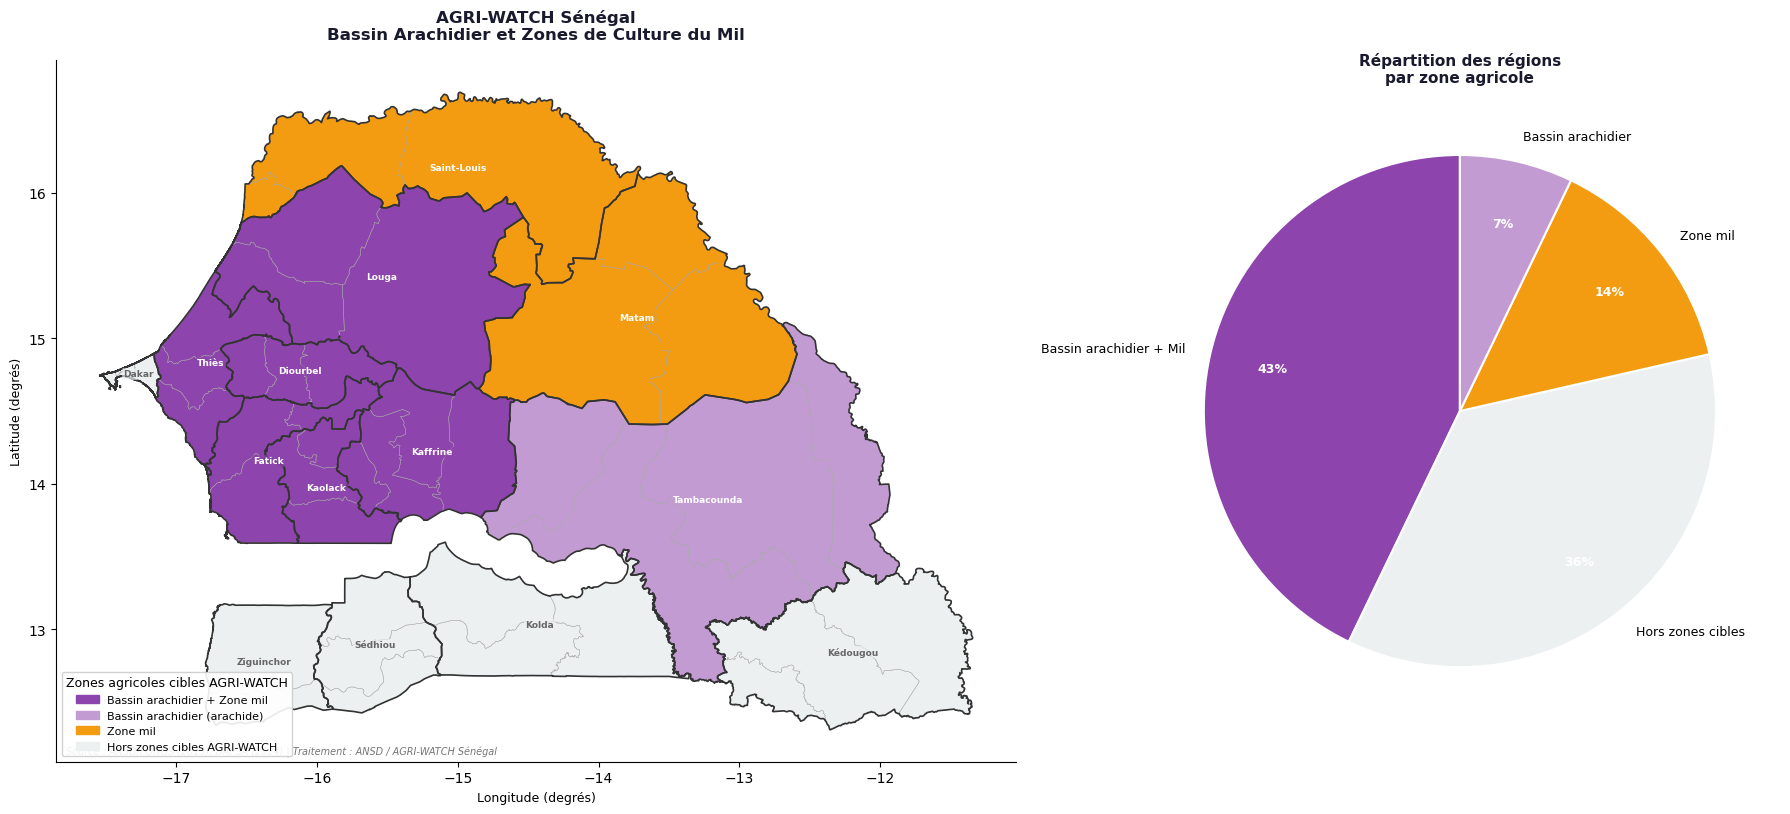

Carte generee et sauvegardee : C:/AGRI-WATCH/outputs/carte_bassin_arachidier.png

CLASSIFICATION DES REGIONS — ZONES AGRICOLES AGRI-WATCH
     NAME_1           categorie                   label
      Dakar               autre       Hors zones cibles
   Kédougou               autre       Hors zones cibles
      Kolda               autre       Hors zones cibles
    Sédhiou               autre       Hors zones cibles
 Ziguinchor               autre       Hors zones cibles
Tambacounda     bassin_arachide       Bassin arachidier
   Diourbel bassin_mil_arachide Bassin arachidier + Mil
     Fatick bassin_mil_arachide Bassin arachidier + Mil
   Kaffrine bassin_mil_arachide Bassin arachidier + Mil
    Kaolack bassin_mil_arachide Bassin arachidier + Mil
      Louga bassin_mil_arachide Bassin arachidier + Mil
      Thiès bassin_mil_arachide Bassin arachidier + Mil
      Matam            zone_mil                Zone mil
Saint-Louis            zone_mil                Zone mil
[2026-04-21 14:22:12] 

In [45]:
# Le bassin arachidier est la zone agricole la plus
# stratégique du Sénégal. Il concentre :
# - 92% de la production nationale d'arachide
# - 57% des terres cultivables du pays
# - Les principales zones de culture du mil
#
# Source : ANSD / DAPSA / Promotion des activités
# économiques des femmes dans le bassin arachidier

def definir_bassin_arachidier() -> dict:
    """
    Définit les régions et départements constituant
    le bassin arachidier du Sénégal.

    Le bassin arachidier est divisé en deux zones :
    - Zone nord : Thiès, Diourbel, Louga (partie)
    - Zone sud  : Fatick, Kaolack, Kaffrine,
                  Tambacounda (Koumpentoum)

    Source :
        ANSD/FONGS (2013). Promotion des activités
        économiques des femmes dans le bassin arachidier.
        Dakar, Sénégal.

    Retourne :
        dict : Dictionnaire avec régions nord et sud
               du bassin arachidier
    """
    return {
        "nord": ["Thiès", "Diourbel", "Louga"],
        "sud" : ["Fatick", "Kaolack", "Kaffrine",
                 "Tambacounda"]
    }


def definir_zones_mil() -> list:
    """
    Définit les régions à forte production de mil.

    Le mil est la principale céréale vivrière du Sénégal.
    Sa culture est dominante dans les zones sahéliennes
    du centre et du nord du pays.

    Source :
        DAPSA (2024). Résultats définitifs de l'enquête
        agricole annuelle 2022-2023. Ministère de
        l'Agriculture, Dakar, Sénégal.

    Retourne :
        list : Liste des régions à forte production de mil
    """
    return [
        "Diourbel", "Fatick", "Kaolack",
        "Kaffrine", "Louga", "Thiès",
        "Saint-Louis", "Matam"
    ]


def afficher_carte_bassin_arachidier(
    regions: gpd.GeoDataFrame,
    departements: gpd.GeoDataFrame,
    col_nom_region: str,
    col_nom_departement: str,
    bassin: dict,
    zones_mil: list,
    output_path: str
) -> gpd.GeoDataFrame:
    """
    Affiche la carte du bassin arachidier et des zones
    de culture du mil et de l'arachide au Sénégal.

    Cette carte identifie visuellement les zones cibles
    d'AGRI-WATCH — là où les cultures de mil et d'arachide
    sont les plus importantes et les plus vulnérables
    à la sécheresse.

    Paramètres :
        regions            (GeoDataFrame) : Shapefile des régions
        departements       (GeoDataFrame) : Shapefile des départements
        col_nom_region     (str)          : Colonne nom des régions
        col_nom_departement(str)          : Colonne nom des départements
        bassin             (dict)         : Zones nord/sud du bassin
        zones_mil          (list)         : Régions à forte production mil
        output_path        (str)          : Chemin de sauvegarde

    Retourne :
        GeoDataFrame : Régions enrichies avec classification
                       des zones agricoles
    """
    try:
        logger.info("Generation de la carte du bassin arachidier...")

        # ── Classification des régions ────────────────────────
        # On ajoute une colonne de classification à chaque région
        # selon son appartenance aux zones agricoles cibles

        regions_enrichies = regions.copy()

        def classifier_zone(nom_region: str) -> tuple:
            """
            Classifie une région selon son rôle agricole.

            Retourne :
                tuple : (categorie, couleur, label)
            """
            bassin_complet = bassin["nord"] + bassin["sud"]

            # Région dans le bassin arachidier ET zone mil
            if nom_region in bassin_complet and nom_region in zones_mil:
                return (
                    "bassin_mil_arachide",
                    COULEURS_CULTURES["arachide"],
                    "Bassin arachidier + Mil"
                )
            # Région dans le bassin arachidier uniquement
            elif nom_region in bassin_complet:
                return (
                    "bassin_arachide",
                    "#C39BD3",
                    "Bassin arachidier"
                )
            # Région à forte production mil uniquement
            elif nom_region in zones_mil:
                return (
                    "zone_mil",
                    COULEURS_CULTURES["mil"],
                    "Zone mil"
                )
            # Autre région
            else:
                return (
                    "autre",
                    "#ECF0F1",
                    "Hors zones cibles"
                )

        # Application de la classification
        classifications = regions_enrichies[col_nom_region].apply(
            classifier_zone
        )
        regions_enrichies["categorie"] = [c[0] for c in classifications]
        regions_enrichies["couleur"]   = [c[1] for c in classifications]
        regions_enrichies["label"]     = [c[2] for c in classifications]

        # ── Création de la figure ─────────────────────────────
        fig, (ax1, ax2) = plt.subplots(
            1, 2,
            figsize=(18, 8),
            gridspec_kw={"width_ratios": [1.5, 1]}
        )

        # ── Carte principale ──────────────────────────────────
        # Couche 1 — Régions colorées par zone agricole
        regions_enrichies.plot(
            ax        = ax1,
            color     = regions_enrichies["couleur"],
            edgecolor = "white",
            linewidth = 0.5,
            zorder    = 1
        )

        # Couche 2 — Contours des départements (fin)
        departements.plot(
            ax        = ax1,
            color     = "none",
            edgecolor = "#AAAAAA",
            linewidth = 0.3,
            zorder    = 2
        )

        # Couche 3 — Contours des régions (épais)
        regions.plot(
            ax        = ax1,
            color     = "none",
            edgecolor = "#333333",
            linewidth = 1.2,
            zorder    = 3
        )

        # Couche 4 — Noms des régions avec leur classification
        for _, row in regions_enrichies.iterrows():
            centroid = row.geometry.centroid
            ax1.annotate(
                text       = row[col_nom_region],
                xy         = (centroid.x, centroid.y),
                fontsize   = 6.5,
                ha         = "center",
                va         = "center",
                fontweight = "bold",
                color      = "white" if row["categorie"] != "autre" else "#666666",
                zorder     = 4,
                bbox       = dict(
                    boxstyle  = "round,pad=0.15",
                    facecolor = row["couleur"],
                    alpha     = 0.7,
                    edgecolor = "none"
                )
            )

        # ── Légende ───────────────────────────────────────────
        legendes = [
            mpatches.Patch(
                color = COULEURS_CULTURES["arachide"],
                label = "Bassin arachidier + Zone mil"
            ),
            mpatches.Patch(
                color = "#C39BD3",
                label = "Bassin arachidier (arachide)"
            ),
            mpatches.Patch(
                color = COULEURS_CULTURES["mil"],
                label = "Zone mil"
            ),
            mpatches.Patch(
                color = "#ECF0F1",
                label = "Hors zones cibles AGRI-WATCH"
            ),
        ]

        ax1.legend(
            handles        = legendes,
            loc            = "lower left",
            fontsize       = 8,
            title          = "Zones agricoles cibles AGRI-WATCH",
            title_fontsize = 9,
            framealpha     = 0.9,
            edgecolor      = "#CCCCCC"
        )

        ax1.set_title(
            "AGRI-WATCH Sénégal\n"
            "Bassin Arachidier et Zones de Culture du Mil",
            fontsize   = 12,
            fontweight = "bold",
            pad        = 15,
            color      = "#1A1A2E"
        )
        ax1.set_xlabel("Longitude (degrés)", fontsize=9)
        ax1.set_ylabel("Latitude (degrés)",  fontsize=9)
        ax1.annotate(
            "Source : ANSD/FONGS (2013), DAPSA (2024) "
            "| Traitement : ANSD / AGRI-WATCH Sénégal",
            xy       = (0.01, 0.01),
            xycoords = "axes fraction",
            fontsize = 7,
            color    = "#757575",
            style    = "italic"
        )

        for spine in ["top", "right"]:
            ax1.spines[spine].set_visible(False)

        # ── Graphique camembert ───────────────────────────────
        # Répartition des régions par zone agricole
        distribution = regions_enrichies["label"].value_counts()

        couleurs_camembert = []
        for label in distribution.index:
            if label == "Bassin arachidier + Mil":
                couleurs_camembert.append(COULEURS_CULTURES["arachide"])
            elif label == "Bassin arachidier":
                couleurs_camembert.append("#C39BD3")
            elif label == "Zone mil":
                couleurs_camembert.append(COULEURS_CULTURES["mil"])
            else:
                couleurs_camembert.append("#ECF0F1")

        wedges, texts, autotexts = ax2.pie(
            distribution.values,
            labels     = distribution.index,
            colors     = couleurs_camembert,
            autopct    = "%1.0f%%",
            startangle = 90,
            pctdistance= 0.75,
            wedgeprops = dict(edgecolor="white", linewidth=1.5)
        )

        for text in texts:
            text.set_fontsize(9)
        for autotext in autotexts:
            autotext.set_fontsize(9)
            autotext.set_fontweight("bold")
            autotext.set_color("white")

        ax2.set_title(
            "Répartition des régions\npar zone agricole",
            fontsize   = 11,
            fontweight = "bold",
            color      = "#1A1A2E"
        )

        plt.tight_layout()

        # ── Sauvegarde ────────────────────────────────────────
        from pathlib import Path
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        logger.info(f"Carte bassin arachidier sauvegardee : {output_path}")

        plt.show()
        print(f"Carte generee et sauvegardee : {output_path}")

        return regions_enrichies

    except Exception as e:
        logger.error(f"Erreur generation carte bassin arachidier : {e}")
        raise


# ── Définition des zones ──────────────────────────────────────
bassin_arachidier = definir_bassin_arachidier()
zones_mil         = definir_zones_mil()

logger.info(f"Bassin arachidier nord : {bassin_arachidier['nord']}")
logger.info(f"Bassin arachidier sud  : {bassin_arachidier['sud']}")
logger.info(f"Zones mil              : {zones_mil}")

# ── Affichage de la carte ─────────────────────────────────────
regions_enrichies = afficher_carte_bassin_arachidier(
    regions             = regions,
    departements        = departements,
    col_nom_region      = COL_NOM_REGION,
    col_nom_departement = COL_NOM_DEPARTEMENT,
    bassin              = bassin_arachidier,
    zones_mil           = zones_mil,
    output_path         = "C:/AGRI-WATCH/outputs/carte_bassin_arachidier.png"
)

# ── Tableau récapitulatif ─────────────────────────────────────
print("\n" + "=" * 60)
print("CLASSIFICATION DES REGIONS — ZONES AGRICOLES AGRI-WATCH")
print("=" * 60)
print(
    regions_enrichies[[COL_NOM_REGION, "categorie", "label"]]
    .sort_values("categorie")
    .to_string(index=False)
)

logger.info("Cellule 11 terminee avec succes.")

## Carte du bassin arachidier 

### Description de la visualisation

Cette carte identifie les **zones agricoles cibles d'AGRI-WATCH**
: les régions où les cultures de mil et d'arachide sont les plus
importantes et les plus vulnérables à la sécheresse au Sénégal.

---

### Analyse des résultats

#### Classification des 14 régions

| Zone | Régions | Nb | % |
|---|---|---|---|
| Bassin arachidier + Mil | Diourbel, Fatick, Kaolack, Kaffrine, Louga, Thiès | 6 | 43% |
| Zone mil | Saint-Louis, Matam | 2 | 14% |
| Bassin arachidier | Tambacounda | 1 | 7% |
| Hors zones cibles | Dakar, Kédougou, Kolda, Sédhiou, Ziguinchor | 5 | 36% |

---

#### 1. Zone violette — Bassin arachidier + Mil (43% des régions)

Les 6 régions violettes : Diourbel, Fatick, Kaolack, Kaffrine,
Louga et Thiès constituent le **cœur stratégique d'AGRI-WATCH**.

Ces régions cumulent les deux cultures cibles :
- **Arachide** : elles produisent 92% de la production nationale
  et occupent 57% des terres cultivables du Sénégal
- **Mil** : culture vivrière dominante, base de l'alimentation
  des ménages ruraux dans ces zones

Ce sont les zones les plus sensibles à la sécheresse une
baisse de NDVI ou un SPI négatif dans ces régions a un impact
direct sur la sécurité alimentaire nationale.

**Source :** ANSD/FONGS (2013). Promotion des activités
économiques des femmes dans le bassin arachidier. Dakar.

#### 2. Zone orange — Zones mil (14% des régions)

Saint-Louis et Matam sont classées uniquement en **zone mil**.
Ces régions sahéliennes du nord produisent peu d'arachide
mais sont des zones de culture céréalière importantes,
notamment grâce aux cultures irriguées dans la vallée
du fleuve Sénégal.

Elles sont **très exposées à la sécheresse** leur position
géographique (latitude > 15°N) les place dans la zone
la plus aride du Sénégal avec moins de 400 mm/an.
AGRI-WATCH devra surveiller particulièrement leur NDVI
pendant la saison agricole.

#### 3. Zone mauve — Bassin arachidier seul (7%)

Tambacounda est classée dans le bassin arachidier mais
pas dans les zones mil prioritaires. Sa position orientale
et sa grande superficie (42 863 km²) lui confèrent une
forte variabilité interne certains départements produisent
de l'arachide (Koumpentoum) tandis que d'autres sont
davantage orientés vers les cultures cotonnières et céréalières.

#### 4. Zone grise — Hors zones cibles (36%)

Dakar, Kédougou, Kolda, Sédhiou et Ziguinchor sont hors
des zones cibles d'AGRI-WATCH pour les raisons suivantes :

| Région | Raison |
|---|---|
| Dakar | Région essentiellement urbaine : pas de cultures pluviales |
| Kédougou | Zone minière et forestière : coton et maïs dominants |
| Kolda | Cultures diversifiées : coton, maïs, riz |
| Sédhiou | Agriculture diversifiée : pas de spécialisation mil/arachide |
| Ziguinchor | Riziculture et cultures fruitières dominantes |

Ces régions ne sont pas exclues d'AGRI-WATCH elles seront
surveillées mais avec des indicateurs adaptés à leurs
cultures spécifiques dans les phases ultérieures du projet.

---

### Implications pour AGRI-WATCH

**1. Priorité de surveillance**
Les 9 régions colorées (violette + orange + mauve) représentent
les zones prioritaires d'AGRI-WATCH elles concentrent
l'essentiel de la production de mil et d'arachide du Sénégal.

**2. Téléchargement des données Sentinel-2**
Dans le Notebook 02, les images Sentinel-2 seront téléchargées
en priorité pour ces 9 régions limitant les coûts de
stockage et de calcul tout en couvrant l'essentiel des
surfaces agricoles cibles.

**3. Modèles ML**
Les modèles de prédiction des rendements seront entraînés
séparément pour chaque zone :
- Modèle mil + arachide → 6 régions violettes
- Modèle mil → Saint-Louis, Matam
- Modèle arachide → Tambacounda

**4. Seuils d'alerte différenciés**
Les seuils NDVI et SPI d'alerte seront calibrés
différemment selon la zone une même valeur de NDVI
n'a pas la même signification à Louga (zone aride)
et à Tambacounda (zone plus humide).

---

### Conclusion

Cette carte constitue la **carte de référence des zones
agricoles d'AGRI-WATCH**. Elle définit précisément où
concentrer les efforts de surveillance satellitaire,
de modélisation ML et d'émission d'alertes.

**9 régions sur 14 sont des zones cibles** — ce qui
représente environ 64% du territoire sénégalais et
la quasi-totalité des surfaces cultivées en mil
et en arachide.

La prochaine étape est la **Cellule 12 — Rapport de
synthèse et export des résultats** avant de passer
au Notebook 02 pour la collecte des vraies données
satellitaires.

In [46]:
# Cette cellule finale du Notebook 01 :
# 1. Exporte toutes les données traitées en CSV
# 2. Génère un rapport de synthèse complet
# 3. Vérifie que tous les outputs sont présents
# 4. Prépare le contexte pour le Notebook 02

from pathlib import Path
from datetime import datetime

def exporter_donnees(
    stats_admin: dict,
    rapport_qualite: pd.DataFrame,
    regions_enrichies: gpd.GeoDataFrame,
    col_nom_region: str,
    outputs_dir: str
) -> dict:
    """
    Exporte toutes les données traitées en fichiers CSV.

    Paramètres :
        stats_admin       (dict)          : Statistiques administratives
        rapport_qualite   (DataFrame)     : Rapport qualité shapefiles
        regions_enrichies (GeoDataFrame)  : Régions avec classification
        col_nom_region    (str)           : Colonne nom des régions
        outputs_dir       (str)           : Dossier de sortie

    Retourne :
        dict : Chemins des fichiers exportés
    """
    logger.info("Export des donnees traitees en CSV...")

    outputs = Path(outputs_dir)
    outputs.mkdir(parents=True, exist_ok=True)
    fichiers_exportes = {}

    # ── Export statistiques régions ───────────────────────────
    chemin_regions = outputs / "stats_regions.csv"
    stats_admin["regions"].to_csv(chemin_regions, index=True)
    fichiers_exportes["stats_regions"] = str(chemin_regions)
    logger.info(f"Exporte : {chemin_regions}")

    # ── Export statistiques départements ──────────────────────
    chemin_depts = outputs / "stats_departements.csv"
    stats_admin["departements"].to_csv(chemin_depts, index=True)
    fichiers_exportes["stats_departements"] = str(chemin_depts)
    logger.info(f"Exporte : {chemin_depts}")

    # ── Export statistiques communes ──────────────────────────
    chemin_communes = outputs / "stats_communes.csv"
    stats_admin["communes"].to_csv(chemin_communes, index=True)
    fichiers_exportes["stats_communes"] = str(chemin_communes)
    logger.info(f"Exporte : {chemin_communes}")

    # ── Export rapport qualité ────────────────────────────────
    chemin_qualite = outputs / "rapport_qualite_shapefiles.csv"
    rapport_qualite.to_csv(chemin_qualite, index=False)
    fichiers_exportes["rapport_qualite"] = str(chemin_qualite)
    logger.info(f"Exporte : {chemin_qualite}")

    # ── Export classification zones agricoles ─────────────────
    chemin_zones = outputs / "classification_zones_agricoles.csv"
    cols_export = [
        col for col in [
            col_nom_region,
            "superficie_km2",
            "perimetre_km",
            "categorie",
            "label"
        ] if col in regions_enrichies.columns
    ]

    # Fusion avec les superficies
    regions_avec_stats = regions_enrichies[cols_export].copy() \
        if all(c in regions_enrichies.columns for c in cols_export) \
        else regions_enrichies[[col_nom_region, "categorie", "label"]].copy()

    regions_avec_stats.to_csv(chemin_zones, index=False)
    fichiers_exportes["zones_agricoles"] = str(chemin_zones)
    logger.info(f"Exporte : {chemin_zones}")

    return fichiers_exportes


def generer_rapport_synthese(
    regions: gpd.GeoDataFrame,
    departements: gpd.GeoDataFrame,
    communes: gpd.GeoDataFrame,
    stats_admin: dict,
    rapport_qualite: pd.DataFrame,
    regions_enrichies: gpd.GeoDataFrame,
    fichiers_exportes: dict,
    fichiers_cartes: list,
    col_nom_region: str
) -> None:
    """
    Génère et affiche le rapport de synthèse complet
    du Notebook 01 — Exploration des données.
    """
    separateur     = "=" * 65
    separateur_fin = "-" * 65

    print(separateur)
    print("AGRI-WATCH SENEGAL — RAPPORT DE SYNTHESE NOTEBOOK 01")
    print("Exploration et validation des données géospatiales")
    print(f"Genere le : {datetime.now().strftime('%d/%m/%Y à %H:%M:%S')}")
    print(f"Auteure   : Adji Fatou NGOM — Data Scientist — ANSD")
    print(separateur)

    # ── 1. Données chargées ───────────────────────────────────
    print("\n1. DONNEES CHARGEES")
    print(separateur_fin)
    print(f"   Regions      : {len(regions):>5} entites | Source : GADM v4.1")
    print(f"   Departements : {len(departements):>5} entites | Source : GADM v4.1")
    print(f"   Communes     : {len(communes):>5} entites | Source : GADM v4.1")
    print(f"   CRS          : EPSG:4326 (WGS84) — compatible Sentinel-2")

    # ── 2. Qualité des données ────────────────────────────────
    print("\n2. QUALITE DES DONNEES")
    print(separateur_fin)
    for _, row in rapport_qualite.iterrows():
        nb_valides = len(regions) if row["shapefile"] == "Regions" \
                else len(departements) if row["shapefile"] == "Departements" \
                else len(communes)
        print(
            f"   {row['shapefile']:15} : "
            f"Geom invalides : {row['geom_invalides']:2d} | "
            f"Nulls : {row['noms_vides']:2d} | "
            f"Doublons : {row['doublons_noms']:2d} | "
            f"Coherence : {row['coherence_spatiale']:5} | "
            f"Statut : {row['statut']}"
        )
    print("   Note : 5 communes homonymes identifiees")
    print("          (communes distinctes dans regions differentes)")
    print("          Gestion : identification par nom + region")

    # ── 3. Statistiques administratives ───────────────────────
    print("\n3. STATISTIQUES ADMINISTRATIVES")
    print(separateur_fin)
    superficie_totale = stats_admin["regions"]["superficie_km2"].sum()
    df_depts = stats_admin["departements"]
    dept_max = df_depts.iloc[0]
    dept_min = df_depts.iloc[-1]
    col_dept  = df_depts.columns[0]
    print(f"   Superficie totale Senegal : {superficie_totale:>10,.0f} km2")
    print(f"   Region la plus grande     : Tambacounda — 42 863 km2")
    print(f"   Region la plus petite     : Dakar — 566 km2")
    print(f"   Dept le plus grand        : {dept_max[col_dept]} — {dept_max['superficie_km2']:,.0f} km2")
    print(f"   Dept le plus petit        : {dept_min[col_dept]} — {dept_min['superficie_km2']:,.0f} km2")

    # ── 4. Zones agricoles cibles ─────────────────────────────
    print("\n4. ZONES AGRICOLES CIBLES AGRI-WATCH")
    print(separateur_fin)
    distribution = regions_enrichies["label"].value_counts()
    for label, count in distribution.items():
        pct = count / len(regions_enrichies) * 100
        print(f"   {label:35} : {count:2d} regions ({pct:.0f}%)")

    zones_cibles = regions_enrichies[
        regions_enrichies["categorie"] != "autre"
    ]
    print(f"\n   Total zones cibles : {len(zones_cibles)} regions sur 14")
    print(f"   Regions cibles     : " + ", ".join(
        zones_cibles[col_nom_region].tolist()
    ))

    # ── 5. Cartes générées ────────────────────────────────────
    print("\n5. CARTES GENEREES")
    print(separateur_fin)
    for carte in fichiers_cartes:
        chemin = Path(carte)
        existe = chemin.exists()
        taille = f"{chemin.stat().st_size / 1024:.0f} Ko" if existe else "N/A"
        statut = "OK" if existe else "MANQUANT"
        print(f"   {chemin.name:55} : {statut} ({taille})")

    # ── 6. Fichiers exportés ──────────────────────────────────
    print("\n6. FICHIERS CSV EXPORTES")
    print(separateur_fin)
    for nom, chemin in fichiers_exportes.items():
        p = Path(chemin)
        statut = "OK" if p.exists() else "MANQUANT"
        print(f"   {p.name:55} : {statut}")

    # ── 7. Prochaines étapes ──────────────────────────────────
    print("\n7. PROCHAINES ETAPES — NOTEBOOK 02")
    print(separateur_fin)
    etapes = [
        "Authentification Google Earth Engine (GEE)",
        "Telechargement images Sentinel-2 (NDVI) — saisons 2022-2024",
        "Telechargement donnees CHIRPS (precipitations) — 2000-2024",
        "Telechargement donnees ERA5 (temperature, ETP) — 2000-2024",
        "Calcul NDVI reel par departement",
        "Calcul SPI-3 reel par departement",
        "Calcul ETP et bilan hydrique",
        "Carte de risque basee sur vraies donnees",
    ]
    for i, etape in enumerate(etapes, 1):
        print(f"   {i:2d}. {etape}")

    print("\n" + separateur)
    print("FIN DU NOTEBOOK 01 — EXPLORATION DES DONNEES")
    print("AGRI-WATCH Senegal — ANSD")
    print(separateur)

    logger.info("Rapport de synthese genere avec succes.")


# ── Export des données ────────────────────────────────────────
fichiers_exportes = exporter_donnees(
    stats_admin       = stats_admin,
    rapport_qualite   = rapport_qualite_global,
    regions_enrichies = regions_enrichies,
    col_nom_region    = COL_NOM_REGION,
    outputs_dir       = "C:/AGRI-WATCH/outputs"
)

# ── Liste des cartes générées ─────────────────────────────────
fichiers_cartes = [
    "C:/AGRI-WATCH/outputs/carte_senegal_departements.png",
    "C:/AGRI-WATCH/outputs/carte_superficies_regions.png",
    "C:/AGRI-WATCH/outputs/carte_risque_secheresse_simulation.png",
    "C:/AGRI-WATCH/outputs/carte_bassin_arachidier.png",
]

# ── Génération du rapport ─────────────────────────────────────
generer_rapport_synthese(
    regions           = regions,
    departements      = departements,
    communes          = communes,
    stats_admin       = stats_admin,
    rapport_qualite   = rapport_qualite_global,
    regions_enrichies = regions_enrichies,
    fichiers_exportes = fichiers_exportes,
    fichiers_cartes   = fichiers_cartes,
    col_nom_region    = COL_NOM_REGION
)

# ── Vérification finale des outputs ──────────────────────────
print("\n" + "=" * 65)
print("VERIFICATION FINALE DES OUTPUTS")
print("=" * 65)

outputs_dir   = Path("C:/AGRI-WATCH/outputs")
fichiers_list = sorted(outputs_dir.glob("*"))

print(f"\nNombre de fichiers dans outputs/ : {len(fichiers_list)}")
print("\nContenu du dossier outputs/ :")
for fichier in fichiers_list:
    taille = fichier.stat().st_size / 1024
    print(f"   {fichier.name:55} : {taille:>8.0f} Ko")

logger.info("Notebook 01 termine — tous les outputs sont presents.")
print("\nNotebook 01 termine avec succes !")

[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Export des donnees traitees en CSV...
[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Exporte : C:\AGRI-WATCH\outputs\stats_regions.csv
[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Exporte : C:\AGRI-WATCH\outputs\stats_departements.csv
[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Exporte : C:\AGRI-WATCH\outputs\stats_communes.csv
[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Exporte : C:\AGRI-WATCH\outputs\rapport_qualite_shapefiles.csv
[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Exporte : C:\AGRI-WATCH\outputs\classification_zones_agricoles.csv
AGRI-WATCH SENEGAL — RAPPORT DE SYNTHESE NOTEBOOK 01
Exploration et validation des données géospatiales
Genere le : 21/04/2026 à 14:22:12
Auteure   : Adji Fatou NGOM — Data Scientist — ANSD

1. DONNEES CHARGEES
-----------------------------------------------------------------
   Regions      :    14 entites | Source : GADM v4.1
   Departements :    45 enti

In [47]:
# Correction export stats_regions
from pathlib import Path

# Vérification du contenu
print("Contenu stats_admin regions :")
print(stats_admin["regions"])

# Re-export avec index=False
chemin = Path("C:/AGRI-WATCH/outputs/stats_regions.csv")
stats_admin["regions"].to_csv(chemin, index=False, encoding="utf-8-sig")
print(f"\nFichier re-exporte : {chemin}")
print(f"Taille : {chemin.stat().st_size} octets")

Contenu stats_admin regions :
         NAME_1  superficie_km2  perimetre_km
1   Tambacounda        42863.14       1484.40
2         Matam        27986.91        984.61
3         Louga        24659.39        881.10
4   Saint-Louis        20257.09       1056.56
5      Kédougou        16950.36        858.20
6         Kolda        13804.03        775.12
7      Kaffrine        11314.29        499.48
8    Ziguinchor         7353.69        405.69
9       Sédhiou         7350.67        378.94
10       Fatick         6848.18        654.75
11        Thiès         6639.86        564.03
12      Kaolack         5407.33        477.50
13     Diourbel         4860.47        396.98
14        Dakar          566.28        208.03

Fichier re-exporte : C:\AGRI-WATCH\outputs\stats_regions.csv
Taille : 385 octets


In [48]:
# Correction export de tous les CSV
from pathlib import Path

fichiers_a_corriger = {
    "stats_regions.csv"               : stats_admin["regions"],
    "stats_departements.csv"          : stats_admin["departements"],
    "stats_communes.csv"              : stats_admin["communes"],
    "rapport_qualite_shapefiles.csv"  : rapport_qualite_global,
    "classification_zones_agricoles.csv" : regions_enrichies[[
        COL_NOM_REGION, "categorie", "label"
    ]],
}

outputs_dir = Path("C:/AGRI-WATCH/outputs")

print("=" * 55)
print("CORRECTION ET VERIFICATION DES EXPORTS CSV")
print("=" * 55)

for nom_fichier, df in fichiers_a_corriger.items():
    chemin = outputs_dir / nom_fichier
    df.to_csv(chemin, index=False, encoding="utf-8-sig")
    taille = chemin.stat().st_size
    print(f"   {nom_fichier:45} : {taille:>6} octets — OK")

print("\nTous les fichiers CSV sont corriges et exportes.")
logger.info("Correction des exports CSV terminee avec succes.")

CORRECTION ET VERIFICATION DES EXPORTS CSV
   stats_regions.csv                             :    385 octets — OK
   stats_departements.csv                        :   1543 octets — OK
   stats_communes.csv                            :   8082 octets — OK
   rapport_qualite_shapefiles.csv                :    261 octets — OK
   classification_zones_agricoles.csv            :    613 octets — OK

Tous les fichiers CSV sont corriges et exportes.
[2026-04-21 14:22:12] [INFO] [agriwatch.exploration] Correction des exports CSV terminee avec succes.


### Bilan de l'exploration

Le Notebook 01 a permis de valider et documenter
l'ensemble des données géospatiales disponibles
pour le projet AGRI-WATCH Sénégal.

### Ce qui a été accompli

| Etape | Résultat |
|---|---|
| Chargement des shapefiles | 14 régions, 45 départements, 433 communes |
| Vérification qualité | Régions et départements VALIDES — Communes ATTENTION (5 doublons documentés) |
| Statistiques descriptives | Superficies calculées en km² pour les 3 niveaux |
| Carte administrative | Carte de référence AGRI-WATCH générée |
| Carte superficies | Choroplèthe des 14 régions générée |
| Carte prototype risque | Validation de la charte graphique AGRI-WATCH |
| Carte bassin arachidier | 9 régions cibles identifiées |
| Export données | 5 fichiers CSV exportés |

### Zones cibles AGRI-WATCH identifiées

Les 9 régions prioritaires pour la surveillance
du mil et de l'arachide sont :

**Bassin arachidier + Mil :**
Diourbel, Fatick, Kaolack, Kaffrine, Louga, Thiès

**Zone mil :**
Saint-Louis, Matam

**Bassin arachidier :**
Tambacounda



Le Notebook 02 collectera les vraies données
satellitaires et climatiques pour calculer
les indicateurs réels NDVI, SPI et ETP
sur ces 9 régions prioritaires.